In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
df = pd.read_csv('dataset.csv')
print("Dataset Overview: ", df.head().to_string())

Dataset Overview:     Hours_Studied  Attendance Parental_Involvement Access_to_Resources Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality School_Type Peer_Influence  Physical_Activity Learning_Disabilities Parental_Education_Level Distance_from_Home  Gender  Exam_Score
0             23          84                  Low                High                         No            7               73              Low             Yes                  0           Low          Medium      Public       Positive                  3                    No              High School               Near    Male          67
1             19          64                  Low              Medium                         No            8               59              Low             Yes                  2        Medium          Medium      Public       Negative                  4                    No                  Colle

In [134]:
print("les types de données : \n", df.dtypes.to_string())

les types de données : 
 Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64


#### En observant la moyenne et la mediane nous constatant que moyenne ~ mediane =>   distribution des données approximativement normale (symetrique)

#### il n'y pas de valeurs manquantes numeriques

In [135]:
print('La description des données numerics:\n', df.describe().to_string())

La description des données numerics:
        Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  Physical_Activity   Exam_Score
count    6607.000000  6607.000000   6607.00000      6607.000000        6607.000000        6607.000000  6607.000000
mean       19.975329    79.977448      7.02906        75.070531           1.493719           2.967610    67.235659
std         5.990594    11.547475      1.46812        14.399784           1.230570           1.031231     3.890456
min         1.000000    60.000000      4.00000        50.000000           0.000000           0.000000    55.000000
25%        16.000000    70.000000      6.00000        63.000000           1.000000           2.000000    65.000000
50%        20.000000    80.000000      7.00000        75.000000           1.000000           3.000000    67.000000
75%        24.000000    90.000000      8.00000        88.000000           2.000000           4.000000    69.000000
max        44.000000   100.000000     10.0

#### il ya des valeurs manquantes:
- Teacher_Quality, Parental_Education_Level, Distance_from_Home 

In [5]:
print('La description des données categorielles:\n', df.describe(include=['object']).to_string())
result_stats = df.describe(include=['object'])

La description des données categorielles:
        Parental_Involvement Access_to_Resources Extracurricular_Activities Motivation_Level Internet_Access Family_Income Teacher_Quality School_Type Peer_Influence Learning_Disabilities Parental_Education_Level Distance_from_Home Gender
count                  6607                6607                       6607             6607            6607          6607            6529        6607           6607                  6607                     6517               6540   6607
unique                    3                   3                          2                3               2             3               3           2              3                     2                        3                  3      2
top                  Medium              Medium                        Yes           Medium             Yes           Low          Medium      Public       Positive                    No              High School               Near   Male
freq 

Nous constatant qu'il ya des outliers pour hours_students, tutoring_sessions, et exam_score

<Axes: >

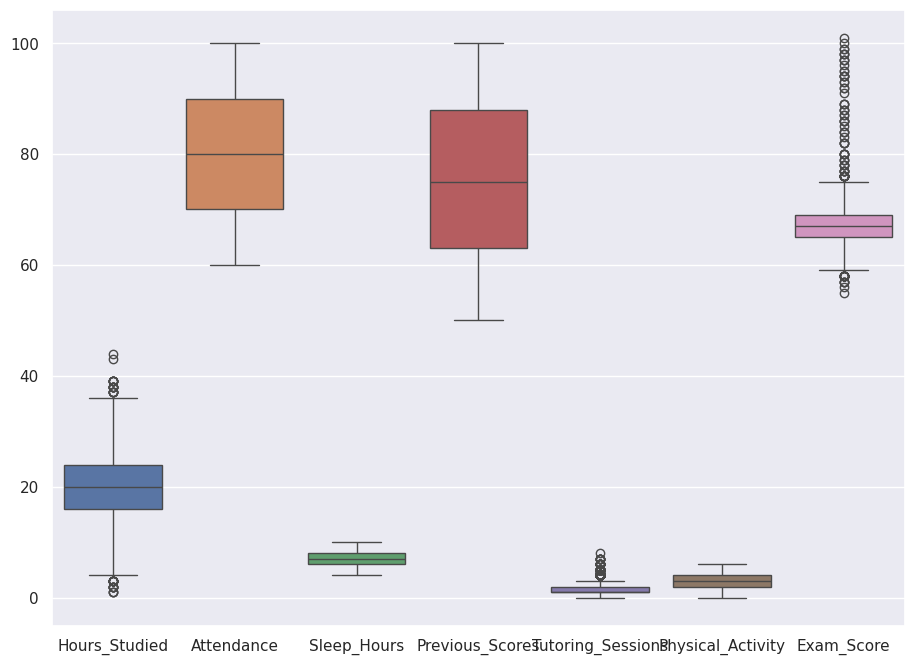

In [6]:
sns.set(rc={'figure.figsize':(11, 8)})
sns.boxplot(data=df)

In [7]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="EduPredict",
    explorative=True)
profile.to_file("rapport_profiling.html")

/tmp/ipykernel_200086/1944718259.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 157.75it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Il n'y a pas de lignes dupliques

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [10]:
df[df['Distance_from_Home'].isna()].tail(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
4638,8,67,Low,Low,No,5,77,Low,Yes,1,Medium,High,Public,Positive,2,No,College,NaN,Male,59
4971,20,75,Low,Medium,Yes,7,97,High,Yes,0,Medium,Medium,Public,Neutral,2,No,College,NaN,Female,66
5056,24,76,High,Low,Yes,8,69,Low,Yes,3,Low,Medium,Private,Negative,1,No,High School,NaN,Male,65
5119,25,84,Medium,Low,No,8,64,Medium,Yes,2,Low,Medium,Private,Neutral,4,No,High School,NaN,Male,67
5207,17,70,Medium,Medium,Yes,6,79,Low,Yes,2,Medium,Medium,Public,Positive,3,No,High School,NaN,Female,64
5229,26,61,Medium,Medium,No,7,64,Low,Yes,0,Medium,Medium,Private,Negative,3,No,Postgraduate,NaN,Male,63
5247,11,78,Low,High,Yes,8,65,Medium,Yes,0,Medium,NaN,Private,Neutral,2,No,High School,NaN,Female,62
5363,14,69,High,Medium,Yes,4,71,Medium,Yes,1,Medium,Medium,Public,Positive,4,No,High School,NaN,Female,64
5724,17,71,Medium,Medium,Yes,6,58,Medium,Yes,3,Medium,Medium,Private,Positive,3,Yes,High School,NaN,Male,64
5725,13,73,Medium,High,No,8,93,Medium,Yes,0,High,High,Public,Neutral,3,No,Postgraduate,NaN,Female,65


Remlissage des valeurs manquates pour Teacher_Quality, Distance_from_Home et Parental_Education_Level  par le mode le plus frequant

In [11]:
df_clean = df.copy() 

df_clean.loc[df_clean['Teacher_Quality'].isna(), 'Teacher_Quality'] = result_stats['Teacher_Quality']['top']

In [12]:
df_clean.loc[df_clean['Parental_Education_Level'].isna(), 'Parental_Education_Level'] = result_stats['Parental_Education_Level']['top']

In [13]:
df_clean.loc[df_clean['Distance_from_Home'].isna(), 'Distance_from_Home'] = result_stats['Distance_from_Home']['top']

In [14]:
df_clean.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

<Axes: >

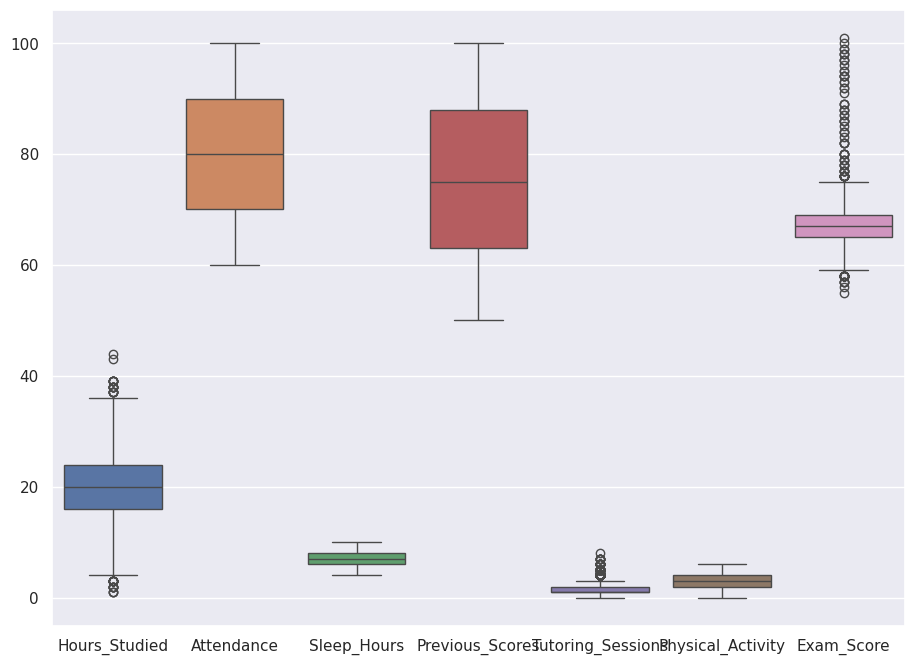

In [15]:
#sns.set(rc={'figure.figsize':(11, 8)})
sns.boxplot(data=df_clean)

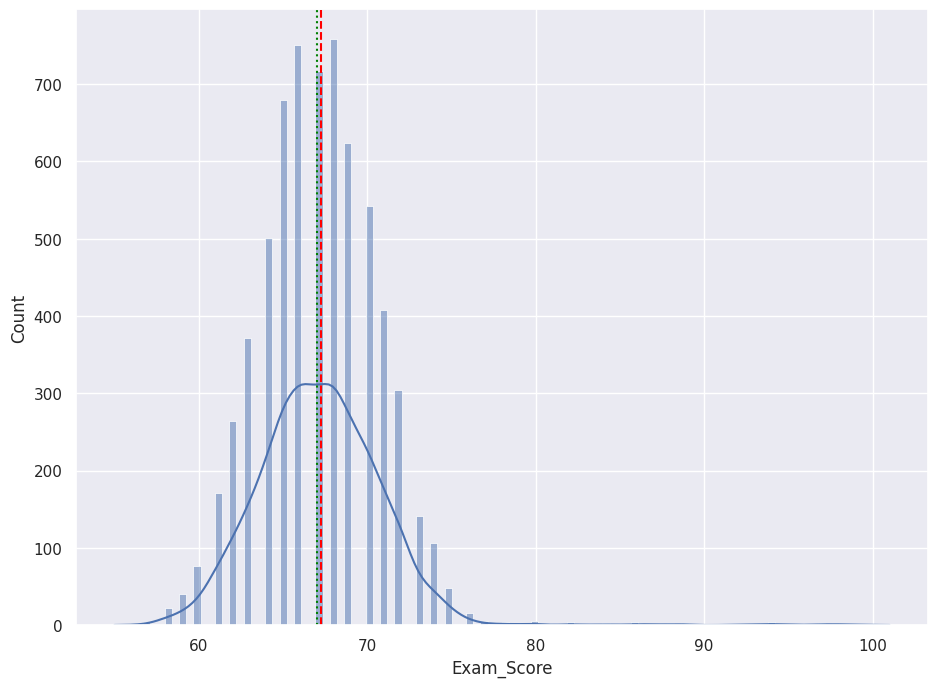

In [16]:

sns.histplot(df_clean, x='Exam_Score', kde=True)
moyenne = df_clean['Exam_Score'].mean()
mediane = df_clean['Exam_Score'].median()

# Affichage des lignes
plt.axvline(moyenne, color='red', linestyle='--', label=f'Moyenne: {moyenne:.2f}')
plt.axvline(mediane, color='green', linestyle=':', label=f'Médiane: {mediane:.2f}')

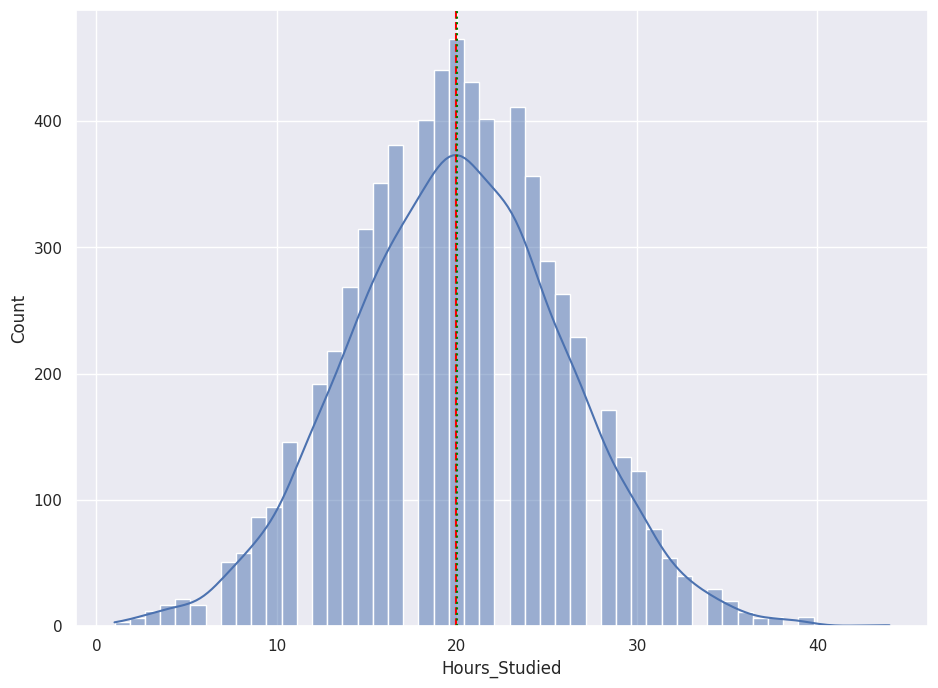

In [17]:
sns.histplot(df_clean, x='Hours_Studied', kde=True)
moyenne = df_clean['Hours_Studied'].mean()
mediane = df_clean['Hours_Studied'].median()

# Affichage des lignes
plt.axvline(moyenne, color='red', linestyle='--', label=f'Moyenne: {moyenne:.2f}')
plt.axvline(mediane, color='green', linestyle=':', label=f'Médiane: {mediane:.2f}')

Remplacement ds outliers pour Hours_studied par le upperlimit et lowerlimit

Hours_Studied

In [18]:
Q1_HS = df_clean['Hours_Studied'].quantile(0.25)
Q3_HS = df_clean['Hours_Studied'].quantile(0.75)
IQR_HS = Q3_HS - Q1_HS

upper_limit_HR = Q3_HS + 1.5 * IQR_HS
lower_limit_HR = Q1_HS- 1.5 * IQR_HS
print(upper_limit_HR)
print(lower_limit_HR)


36.0
4.0


In [19]:
outliers_above = df_clean[df_clean['Hours_Studied'] > upper_limit_HR]
outliers_below = df_clean[df_clean['Hours_Studied'] < lower_limit_HR]

print(outliers_above.shape)



(22, 20)


In [20]:
print(outliers_below.shape)


(21, 20)


<Axes: >

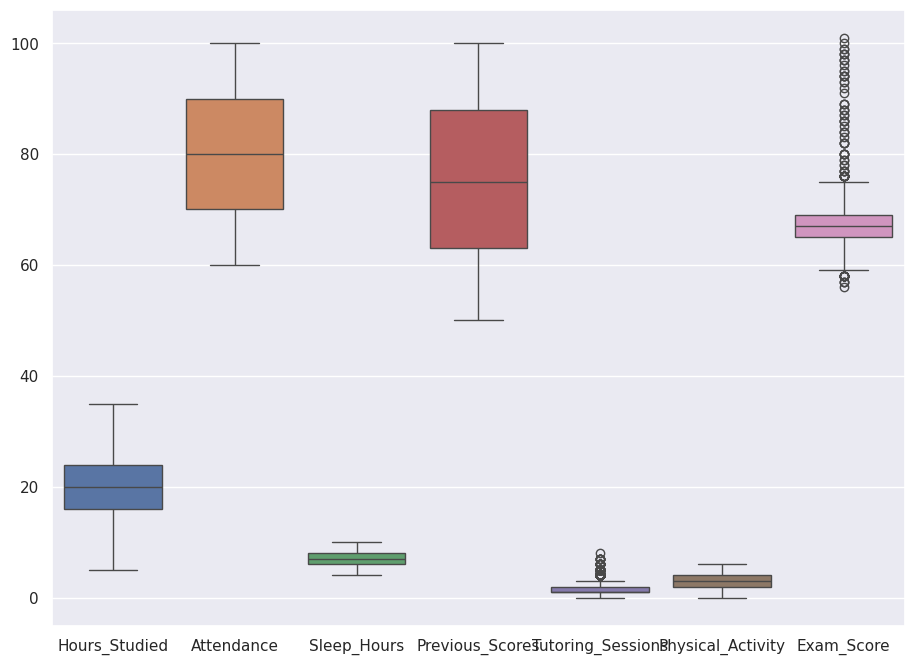

In [21]:


df_clean = df_clean[df_clean['Hours_Studied'] < upper_limit_HR]
   
df_clean = df_clean[df_clean['Hours_Studied'] > lower_limit_HR]
       
sns.boxplot(df_clean)

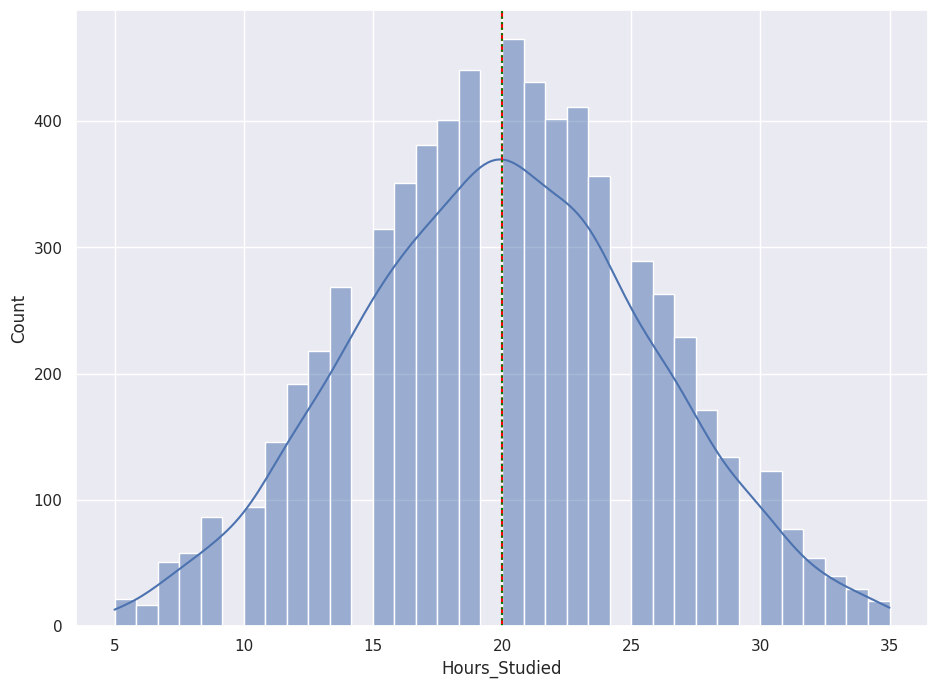

In [22]:
sns.histplot(df_clean, x='Hours_Studied', kde=True)
moyenne = df_clean['Hours_Studied'].mean()
mediane = df_clean['Hours_Studied'].median()

# Affichage des lignes
plt.axvline(moyenne, color='red', linestyle='--', label=f'Moyenne: {moyenne:.2f}')
plt.axvline(mediane, color='green', linestyle=':', label=f'Médiane: {mediane:.2f}')

tutoring_Sessions

In [23]:
Q1_TS = df_clean['Tutoring_Sessions'].quantile(0.25)
Q3_TS = df_clean['Tutoring_Sessions'].quantile(0.75)
IQR_TS = Q3_TS - Q1_TS

upper_limit_TS = Q3_TS + 1.5 * IQR_TS
lower_limit_TS = Q1_TS- 1.5 * IQR_TS
print(upper_limit_TS)
print(lower_limit_TS)


3.5
-0.5


<Axes: >

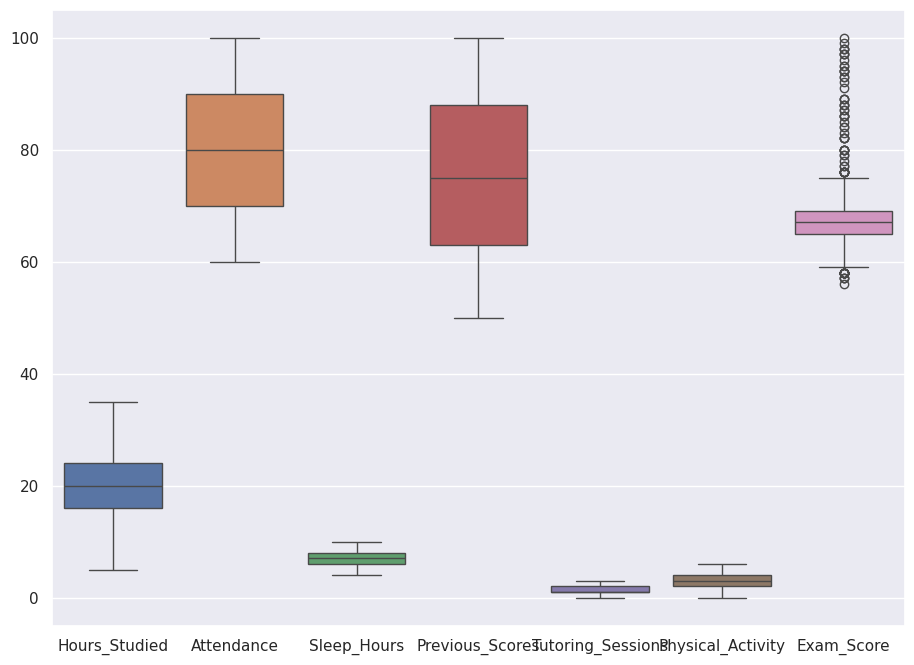

In [24]:
df_clean = df_clean[df_clean['Tutoring_Sessions'] > lower_limit_TS]
df_clean = df_clean[df_clean['Tutoring_Sessions'] < upper_limit_TS]
    
sns.boxplot(df_clean)

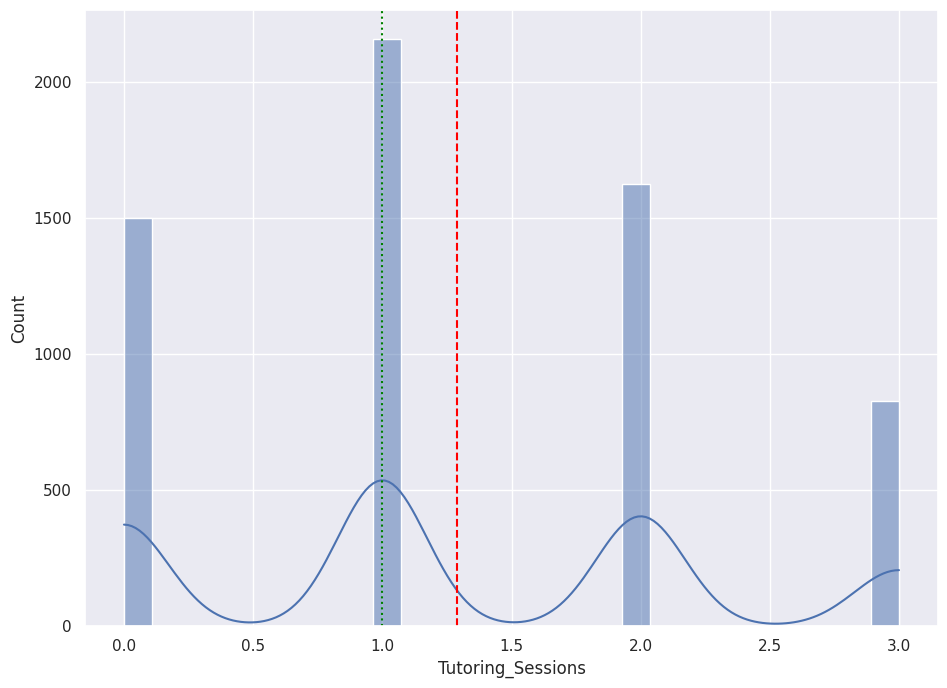

In [25]:
sns.histplot(df_clean, x='Tutoring_Sessions', kde=True)
moyenne = df_clean['Tutoring_Sessions'].mean()
mediane = df_clean['Tutoring_Sessions'].median()

# Affichage des lignes
plt.axvline(moyenne, color='red', linestyle='--', label=f'Moyenne: {moyenne:.2f}')
plt.axvline(mediane, color='green', linestyle=':', label=f'Médiane: {mediane:.2f}')

Exam_Score

In [26]:
Q1_ES = df_clean['Exam_Score'].quantile(0.25)
Q3_ES = df_clean['Exam_Score'].quantile(0.75)
IQR_ES = Q3_ES - Q1_ES

upper_limit_ES = Q3_ES + 1.5 * IQR_ES
lower_limit_ES = Q1_ES- 1.5 * IQR_ES
print(upper_limit_ES)
print(lower_limit_ES)

75.0
59.0


<Axes: >

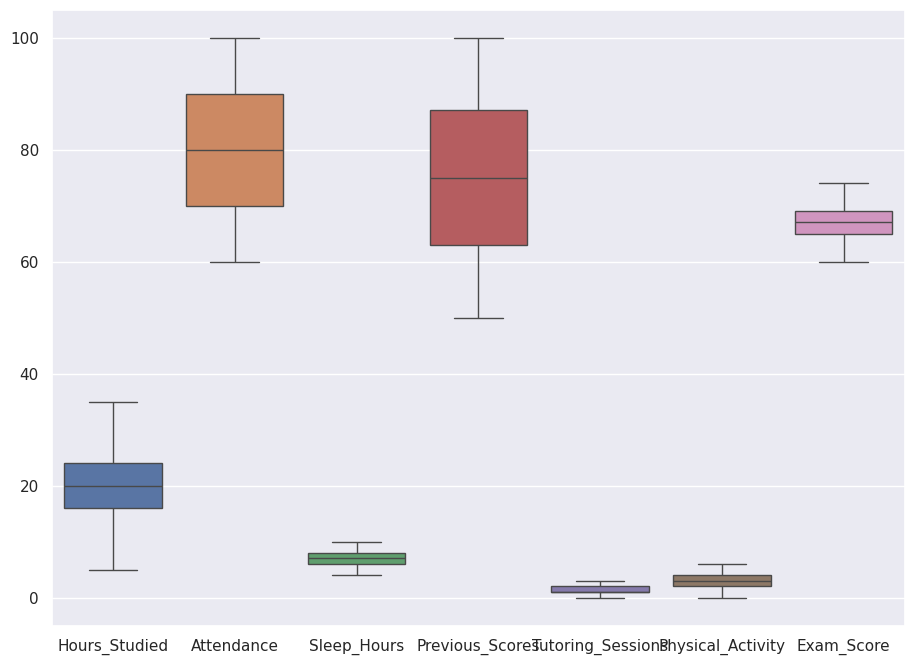

In [27]:
df_clean = df_clean[df_clean['Exam_Score'] < upper_limit_ES]
df_clean = df_clean[df_clean['Exam_Score'] > lower_limit_ES]

sns.boxplot(df_clean)

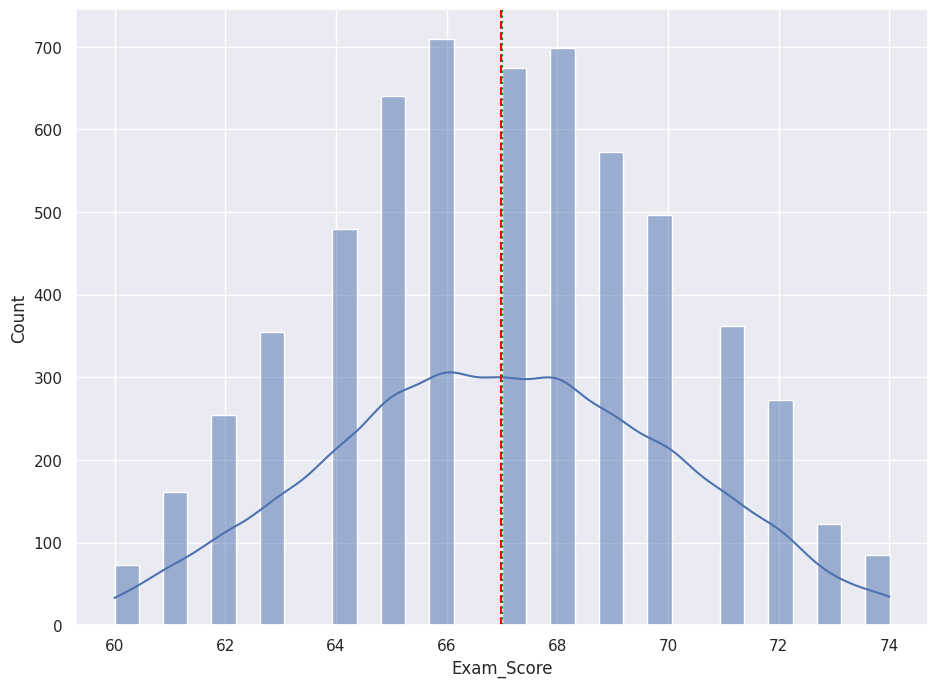

In [28]:
sns.histplot(df_clean, x='Exam_Score', kde=True)
moyenne = df_clean['Exam_Score'].mean()
mediane = df_clean['Exam_Score'].median()

# Affichage des lignes
plt.axvline(moyenne, color='red', linestyle='--', label=f'Moyenne: {moyenne:.2f}')
plt.axvline(mediane, color='green', linestyle=':', label=f'Médiane: {mediane:.2f}')

In [29]:
df_clean.shape

(5957, 20)

One-hot encoding des variables nominales 

In [30]:
df_clean = pd.get_dummies(df_clean, columns=['Gender', 'School_Type', 'Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities', 'Peer_Influence'], dtype=int)
df_clean

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,School_Type_Public,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive
0,23,84,Low,High,7,73,Low,0,Low,Medium,...,1,1,0,0,1,1,0,0,0,1
1,19,64,Low,Medium,8,59,Low,2,Medium,Medium,...,1,1,0,0,1,1,0,1,0,0
2,24,98,Medium,Medium,7,91,Medium,2,Medium,Medium,...,1,0,1,0,1,1,0,0,1,0
3,29,89,Low,Medium,8,98,Medium,1,Medium,Medium,...,1,0,1,0,1,1,0,1,0,0
4,19,92,Medium,Medium,6,65,Medium,3,Medium,High,...,1,0,1,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,7,76,Medium,1,High,Medium,...,1,1,0,0,1,1,0,0,0,1
6603,23,76,High,Medium,8,81,Medium,3,Low,High,...,1,1,0,0,1,1,0,0,0,1
6604,20,90,Medium,Low,6,65,Low,3,Low,Medium,...,1,0,1,0,1,1,0,1,0,0
6605,10,86,High,High,6,91,High,2,Low,Medium,...,0,0,1,0,1,1,0,0,0,1


Encodage ordinal des variables ordinales

In [31]:
from sklearn.preprocessing import OrdinalEncoder

encoderr = OrdinalEncoder(categories=df['Parental_Involvement'])
encoderr



,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",0 Lo... dtype: object
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None


In [32]:
e = OrdinalEncoder()
df_clean['Parental_Involvement'] = e.fit_transform(df_clean[['Parental_Involvement']])
df_clean['Parental_Involvement']

0       1.0
1       1.0
2       2.0
3       1.0
4       2.0
       ... 
6602    0.0
6603    0.0
6604    2.0
6605    0.0
6606    2.0
Name: Parental_Involvement, Length: 5957, dtype: float64

In [33]:
df_clean['Access_to_Resources'] = e.fit_transform(df_clean[['Access_to_Resources']])
df_clean['Access_to_Resources']

0       0.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
6602    2.0
6603    2.0
6604    1.0
6605    0.0
6606    1.0
Name: Access_to_Resources, Length: 5957, dtype: float64

In [34]:
df_clean['Motivation_Level'] = e.fit_transform(df_clean[['Motivation_Level']])
df_clean['Motivation_Level']

0       1.0
1       1.0
2       2.0
3       2.0
4       2.0
       ... 
6602    2.0
6603    2.0
6604    1.0
6605    0.0
6606    2.0
Name: Motivation_Level, Length: 5957, dtype: float64

In [35]:
df_clean['Family_Income'] = e.fit_transform(df_clean[['Family_Income']])
df_clean['Family_Income']

0       1.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
6602    0.0
6603    1.0
6604    1.0
6605    1.0
6606    2.0
Name: Family_Income, Length: 5957, dtype: float64

In [36]:
df_clean['Teacher_Quality'] = e.fit_transform(df_clean[['Teacher_Quality']])
df_clean['Teacher_Quality']

0       2.0
1       2.0
2       2.0
3       2.0
4       0.0
       ... 
6602    2.0
6603    0.0
6604    2.0
6605    2.0
6606    2.0
Name: Teacher_Quality, Length: 5957, dtype: float64

In [37]:
df_clean['Parental_Education_Level'] = e.fit_transform(df_clean[['Parental_Education_Level']])
df_clean['Parental_Education_Level']

0       1.0
1       0.0
2       2.0
3       1.0
4       0.0
       ... 
6602    1.0
6603    1.0
6604    2.0
6605    1.0
6606    2.0
Name: Parental_Education_Level, Length: 5957, dtype: float64

In [38]:
df_clean['Distance_from_Home'] = e.fit_transform(df_clean[['Distance_from_Home']])
df_clean['Distance_from_Home']

0       2.0
1       1.0
2       2.0
3       1.0
4       2.0
       ... 
6602    2.0
6603    2.0
6604    2.0
6605    0.0
6606    2.0
Name: Distance_from_Home, Length: 5957, dtype: float64

In [39]:
df_clean

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,School_Type_Public,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive
0,23,84,1.0,0.0,7,73,1.0,0,1.0,2.0,...,1,1,0,0,1,1,0,0,0,1
1,19,64,1.0,2.0,8,59,1.0,2,2.0,2.0,...,1,1,0,0,1,1,0,1,0,0
2,24,98,2.0,2.0,7,91,2.0,2,2.0,2.0,...,1,0,1,0,1,1,0,0,1,0
3,29,89,1.0,2.0,8,98,2.0,1,2.0,2.0,...,1,0,1,0,1,1,0,1,0,0
4,19,92,2.0,2.0,6,65,2.0,3,2.0,0.0,...,1,0,1,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,0.0,2.0,7,76,2.0,1,0.0,2.0,...,1,1,0,0,1,1,0,0,0,1
6603,23,76,0.0,2.0,8,81,2.0,3,1.0,0.0,...,1,1,0,0,1,1,0,0,0,1
6604,20,90,2.0,1.0,6,65,1.0,3,1.0,2.0,...,1,0,1,0,1,1,0,1,0,0
6605,10,86,0.0,0.0,6,91,0.0,2,1.0,2.0,...,0,0,1,0,1,1,0,0,0,1


In [114]:
from sklearn.model_selection import train_test_split
x  = df_clean[df_clean.columns.difference(['Exam_Score'])]
y = df_clean['Exam_Score']
x_train, x_test,y_train, y_test = train_test_split(x, y,test_size=0.20, random_state=25)
print(y_train.to_string, y_test.to_string, x_train.to_string, x_test.to_string)


<bound method Series.to_string of 6415    66
2961    61
4035    74
6042    67
6295    65
        ..
277     66
3259    72
2426    70
346     62
5817    71
Name: Exam_Score, Length: 4765, dtype: int64> <bound method Series.to_string of 5870    64
289     64
4510    70
1204    65
546     65
        ..
6189    67
6002    61
2003    67
362     63
2011    62
Name: Exam_Score, Length: 1192, dtype: int64> <bound method DataFrame.to_string of       Access_to_Resources  Attendance  Distance_from_Home  \
6415                  2.0          82                 2.0   
2961                  0.0          60                 2.0   
4035                  0.0          93                 2.0   
6042                  1.0          61                 2.0   
6295                  2.0          67                 1.0   
...                   ...         ...                 ...   
277                   0.0          67                 2.0   
3259                  2.0          93                 1.0   
2426        

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
scaler.fit(df_clean)
#print(scaler.mean_)
result = scaler.transform(df_clean)
print(result)

result = pd.DataFrame(result, columns = df_clean.columns)
result

[[ 5.31586145e-01  3.51950220e-01 -2.59662598e-01 ... -5.13239354e-01
  -8.04895120e-01  1.22895260e+00]
 [-1.77235045e-01 -1.39810609e+00 -2.59662598e-01 ...  1.94840866e+00
  -8.04895120e-01 -8.13701035e-01]
 [ 7.08791442e-01  1.57698964e+00  8.94673294e-01 ... -5.13239354e-01
   1.24239789e+00 -8.13701035e-01]
 ...
 [-2.97474060e-05  8.76967112e-01  8.94673294e-01 ...  1.94840866e+00
  -8.04895120e-01 -8.13701035e-01]
 [-1.77208272e+00  5.26955850e-01 -1.41399849e+00 ... -5.13239354e-01
  -8.04895120e-01  1.22895260e+00]
 [-8.86056235e-01 -1.13559764e+00  8.94673294e-01 ... -5.13239354e-01
  -8.04895120e-01  1.22895260e+00]]


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,School_Type_Public,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive
0,0.531586,0.351950,-0.259663,-1.385043,-0.025490,-0.145282,-0.397295,-1.316583,-0.289556,0.768529,...,0.659603,1.211482,-1.211482,-0.287571,0.287571,0.337453,-0.337453,-0.513239,-0.804895,1.228953
1,-0.177235,-1.398106,-0.259663,0.910964,0.655413,-1.121455,-0.397295,0.720265,1.056958,0.768529,...,0.659603,1.211482,-1.211482,-0.287571,0.287571,0.337453,-0.337453,1.948409,-0.804895,-0.813701
2,0.708791,1.576990,0.894673,0.910964,-0.025490,1.109797,0.881303,0.720265,1.056958,0.768529,...,0.659603,-0.825435,0.825435,-0.287571,0.287571,0.337453,-0.337453,-0.513239,1.242398,-0.813701
3,1.594818,0.789464,-0.259663,0.910964,0.655413,1.597883,0.881303,-0.298159,1.056958,0.768529,...,0.659603,-0.825435,0.825435,-0.287571,0.287571,0.337453,-0.337453,1.948409,-0.804895,-0.813701
4,-0.177235,1.051973,0.894673,0.910964,-0.706392,-0.703095,0.881303,1.738689,1.056958,-1.459812,...,0.659603,-0.825435,0.825435,-0.287571,0.287571,0.337453,-0.337453,-0.513239,1.242398,-0.813701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5952,0.885997,-0.960592,-1.413998,0.910964,-0.025490,0.063898,0.881303,-0.298159,-1.636070,0.768529,...,0.659603,1.211482,-1.211482,-0.287571,0.287571,0.337453,-0.337453,-0.513239,-0.804895,1.228953
5953,0.531586,-0.348072,-1.413998,0.910964,0.655413,0.412531,0.881303,1.738689,-0.289556,-1.459812,...,0.659603,1.211482,-1.211482,-0.287571,0.287571,0.337453,-0.337453,-0.513239,-0.804895,1.228953
5954,-0.000030,0.876967,0.894673,-0.237039,-0.706392,-0.703095,-0.397295,1.738689,-0.289556,0.768529,...,0.659603,-0.825435,0.825435,-0.287571,0.287571,0.337453,-0.337453,1.948409,-0.804895,-0.813701
5955,-1.772083,0.526956,-1.413998,-1.385043,-0.706392,1.109797,-1.675892,0.720265,-0.289556,0.768529,...,-1.516064,-0.825435,0.825435,-0.287571,0.287571,0.337453,-0.337453,-0.513239,-0.804895,1.228953


<Axes: xlabel='Exam_Score', ylabel='Count'>

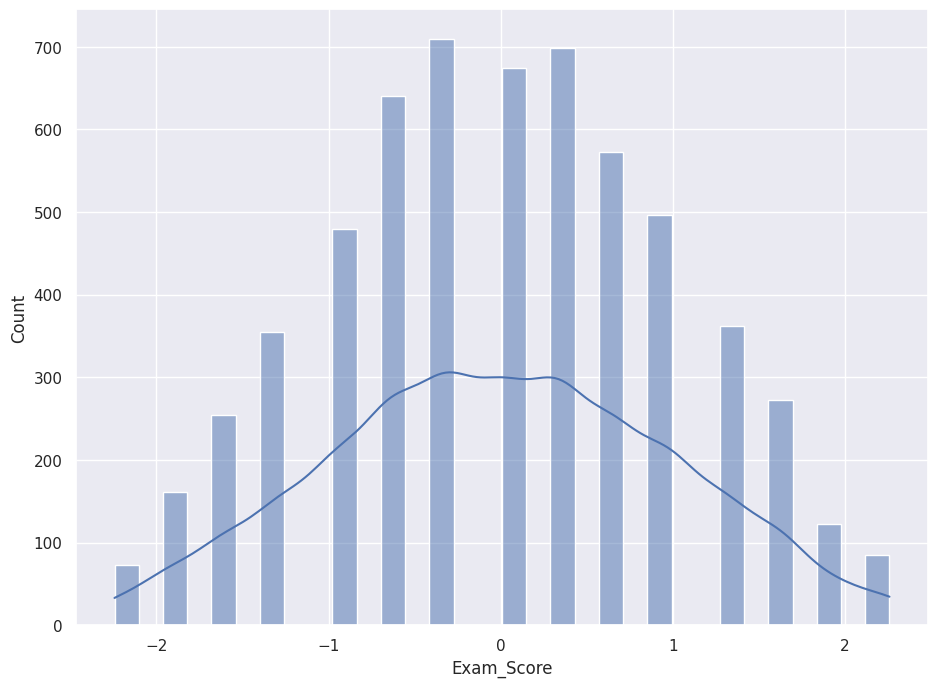

In [43]:
sns.histplot(result['Exam_Score'], kde=True)

### Regression lineaire

In [44]:
from sklearn import linear_model

Creation du model de regression

In [45]:
model= linear_model.LinearRegression()

Entrainer le model

In [46]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](26,)","[-0.4 , 0.2 , 0.5 ,..., 0.01,-0.21, 0.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](26,)","['Access_to_Resources','Attendance','Distance_from_Home',...,'Sleep_Hours', 'Teacher_Quality','Tutoring_Sessions']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,40.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,26
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,20


Prediction

In [47]:
predicted = model.predict(x_train)

In [48]:
print('Predicted : => ', predicted)
print('Target : => ', y_train)

Predicted : =>  [66.07442274 61.52940067 72.99854368 ... 70.93564113 61.69828495
 70.24350405]
Target : =>  6415    66
2961    61
4035    74
6042    67
6295    65
        ..
277     66
3259    72
2426    70
346     62
5817    71
Name: Exam_Score, Length: 4765, dtype: int64


Visualisation du model avec nuage de points

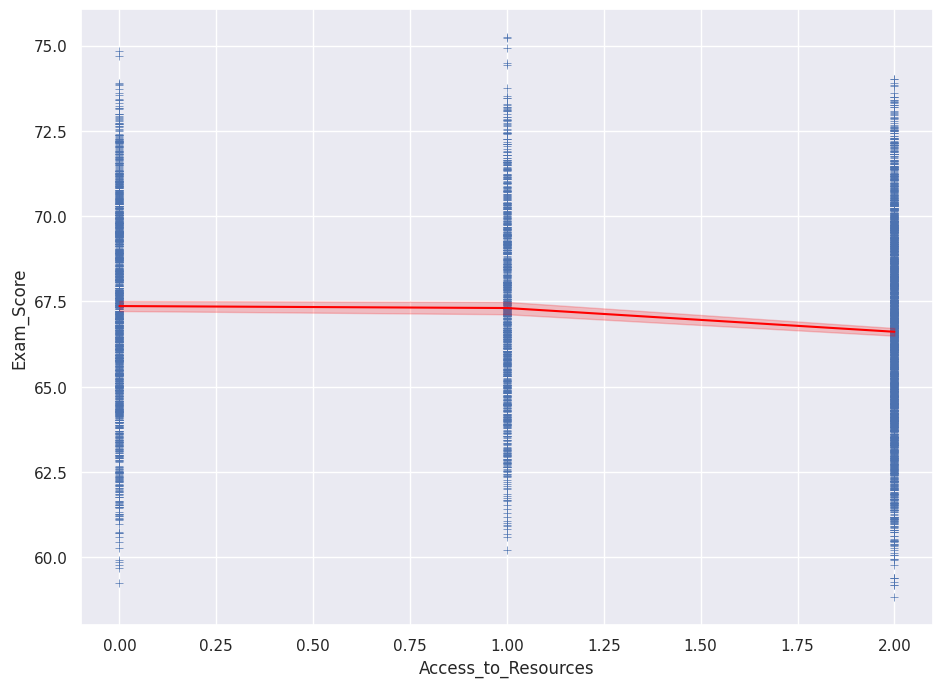

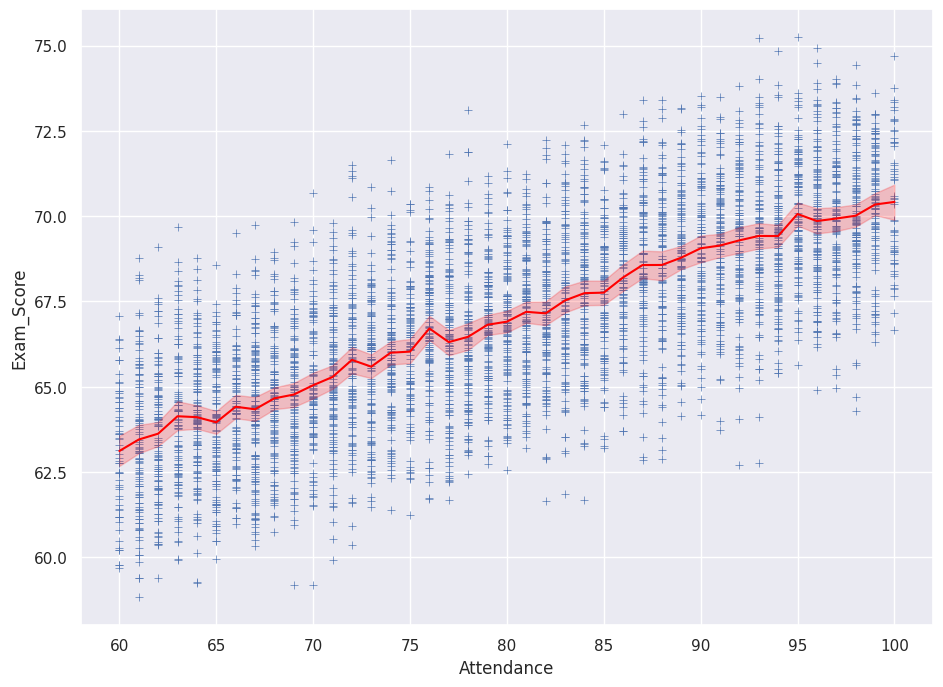

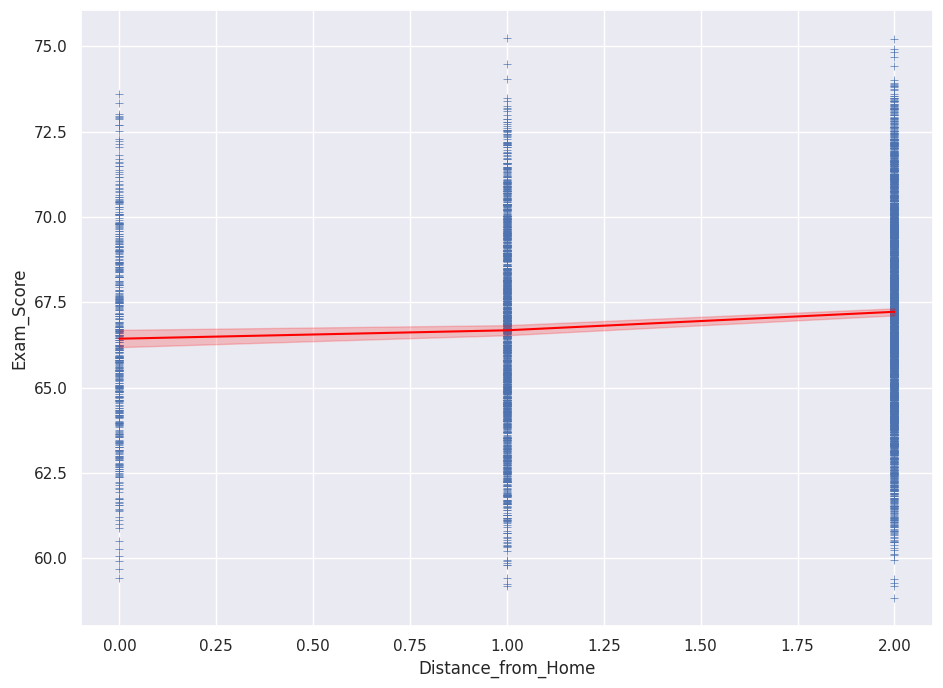

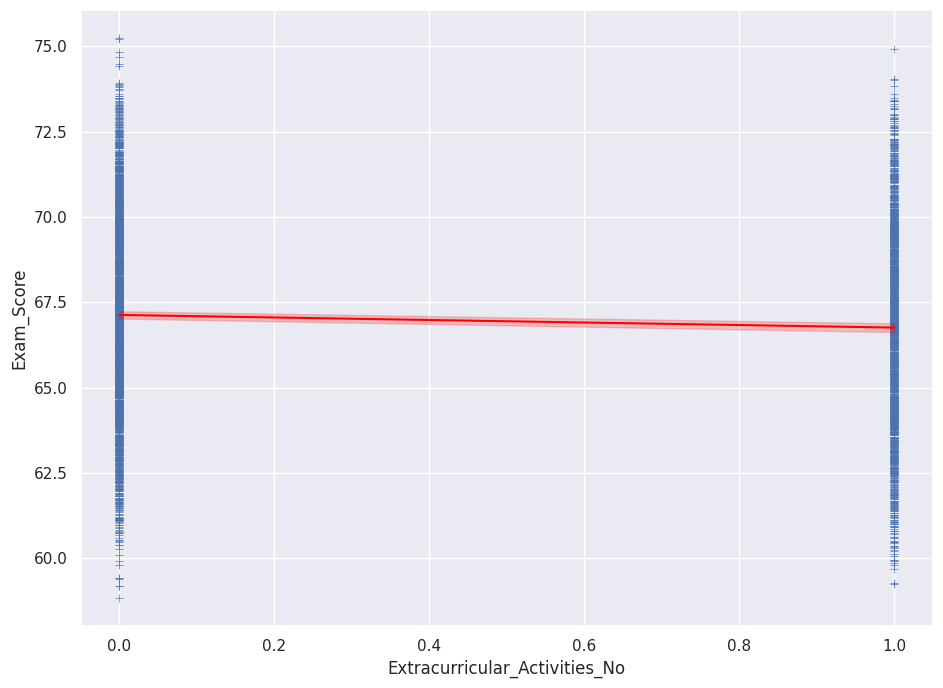

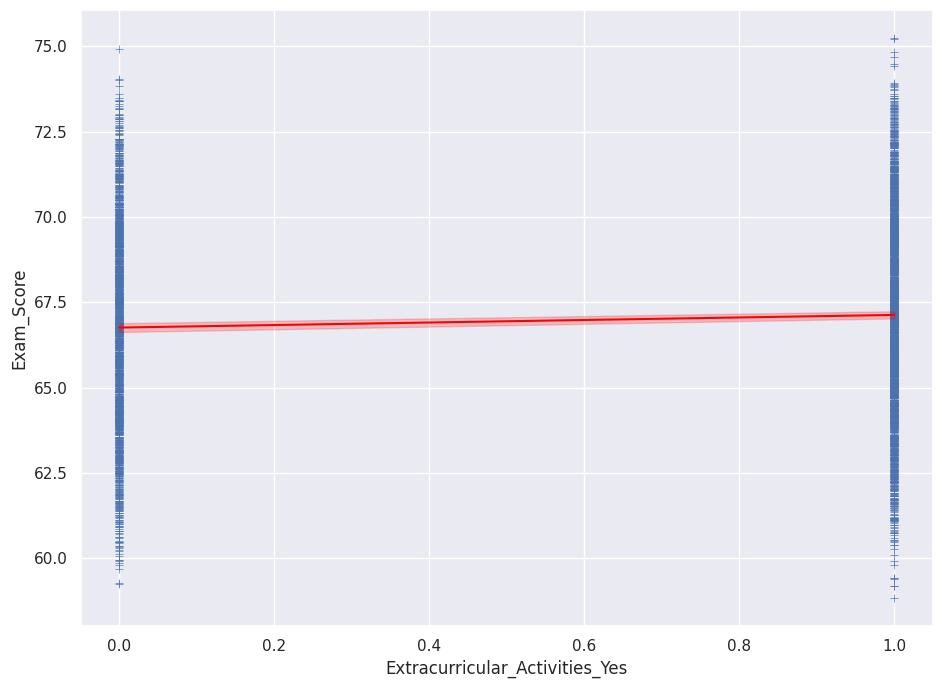

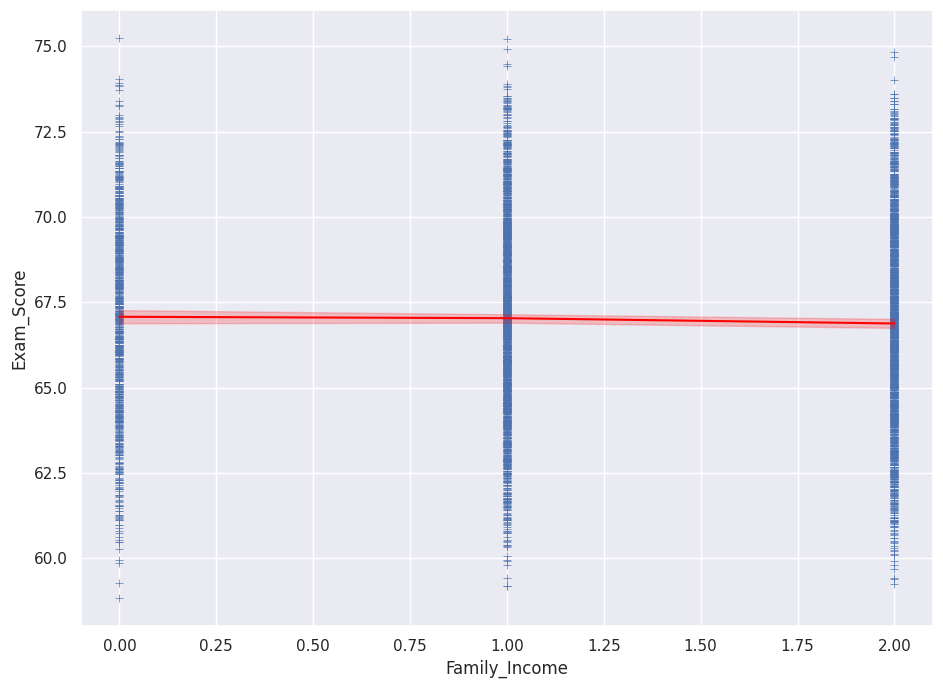

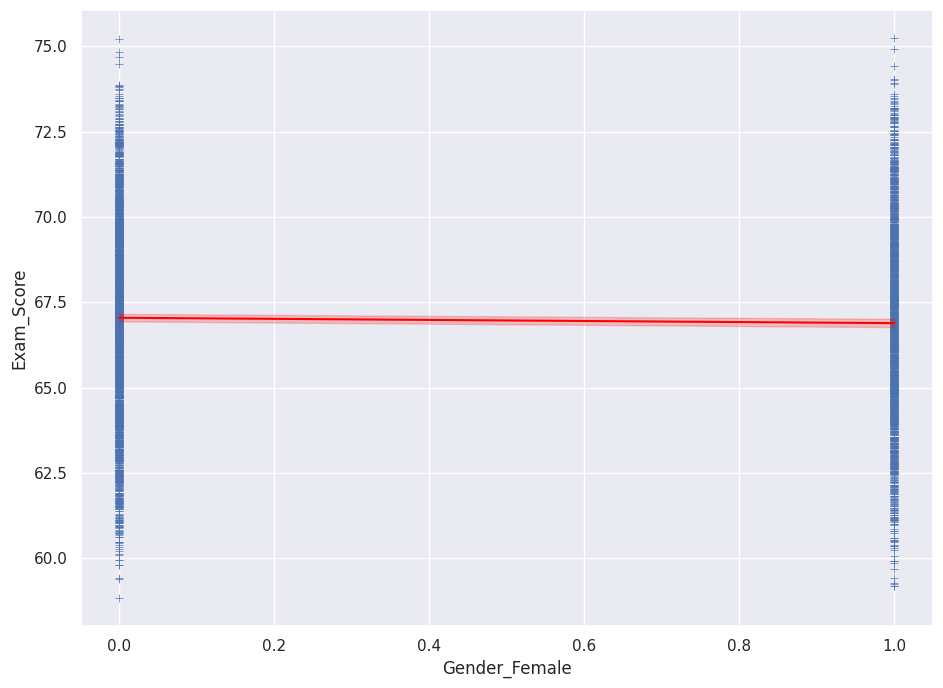

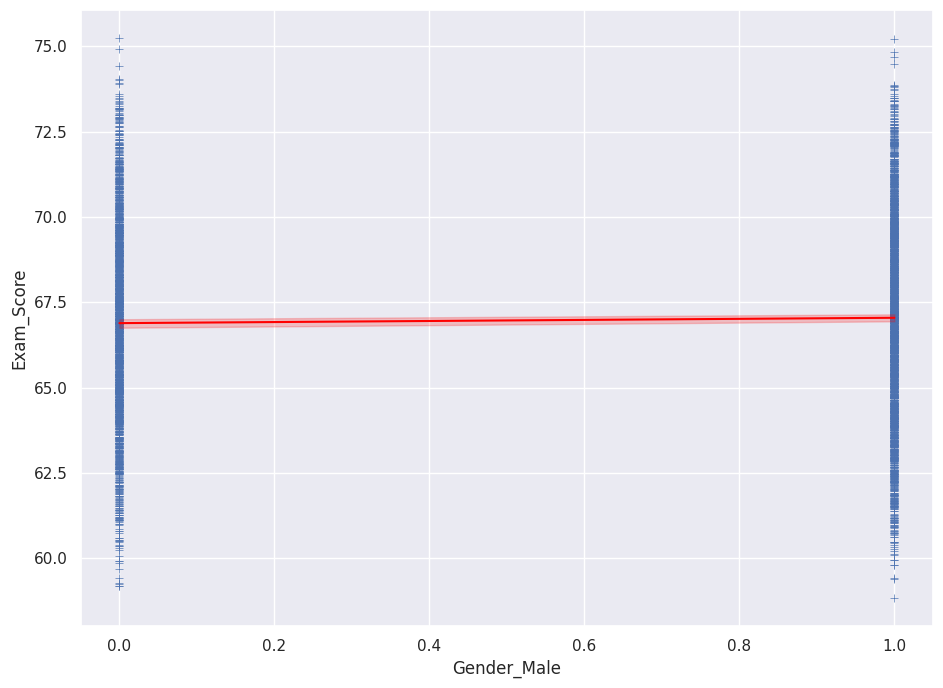

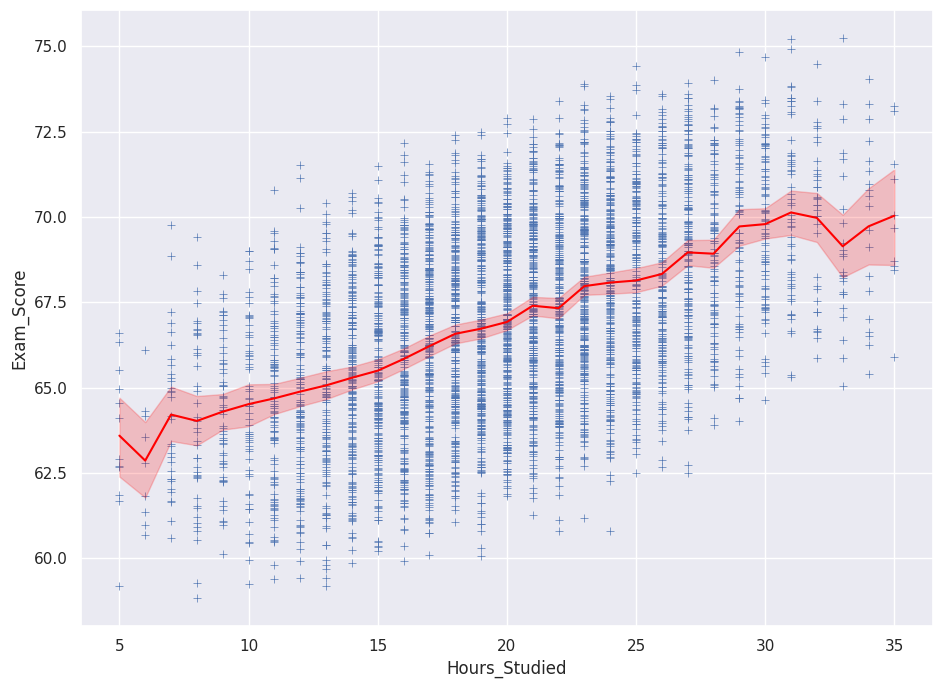

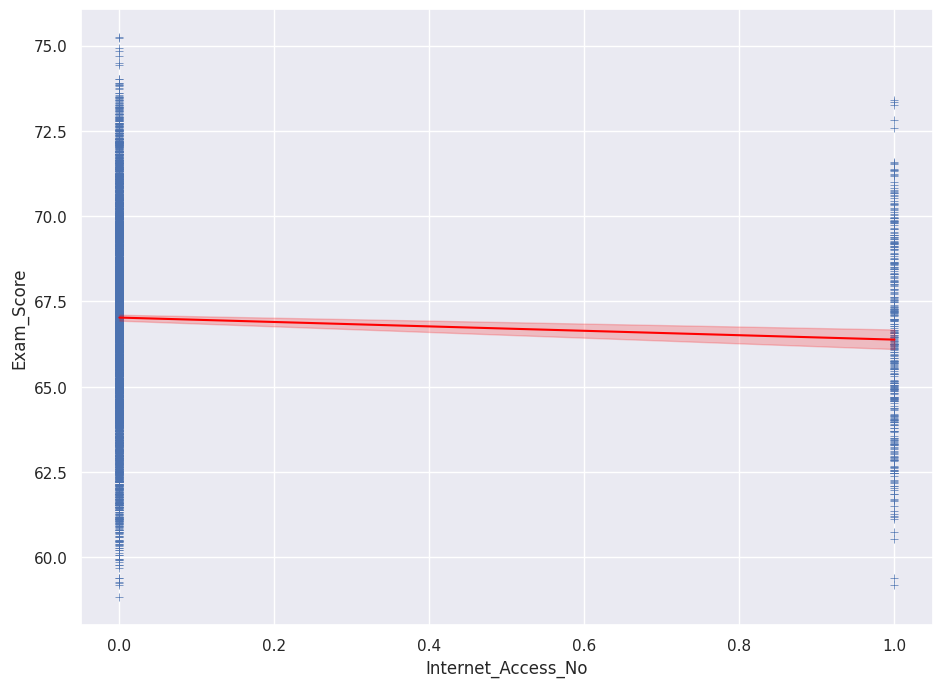

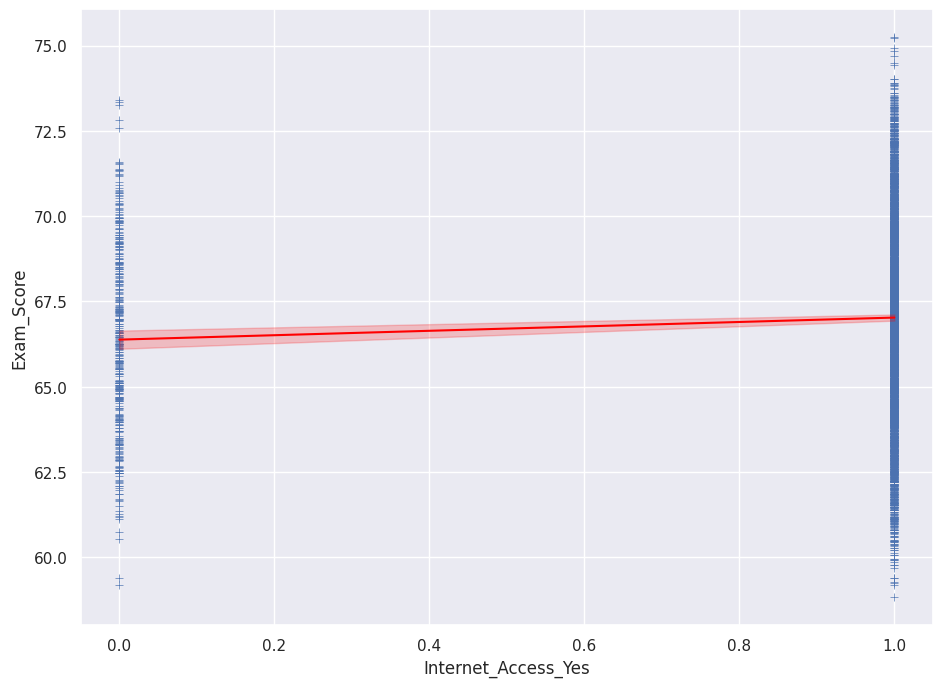

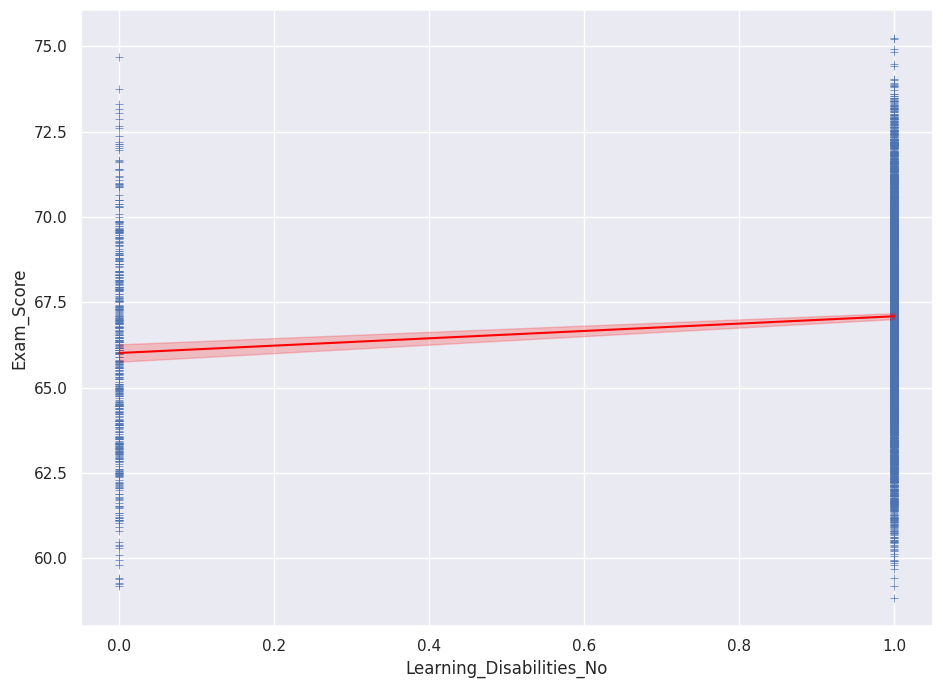

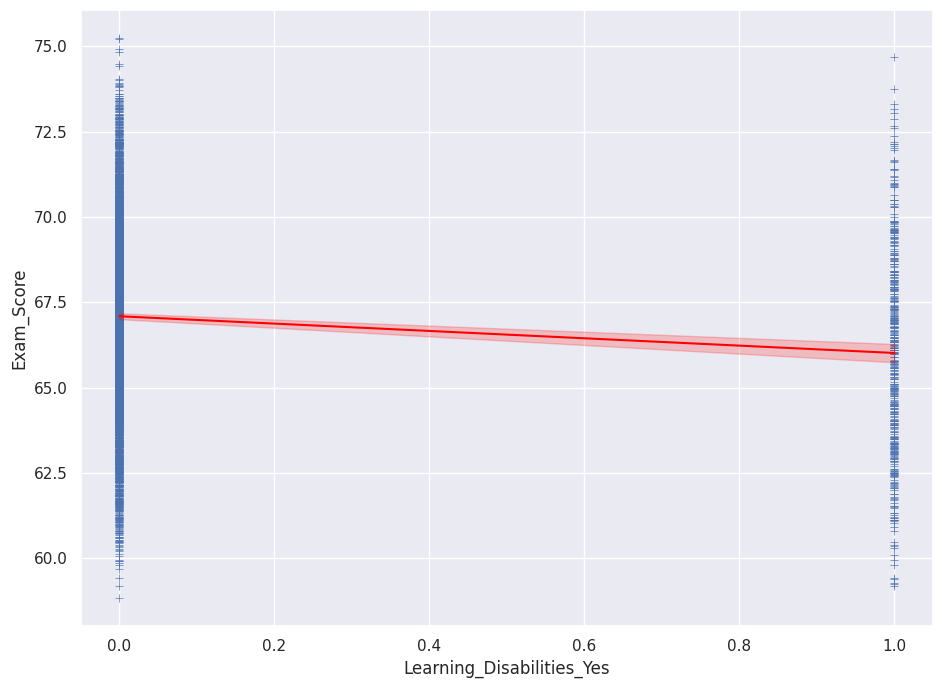

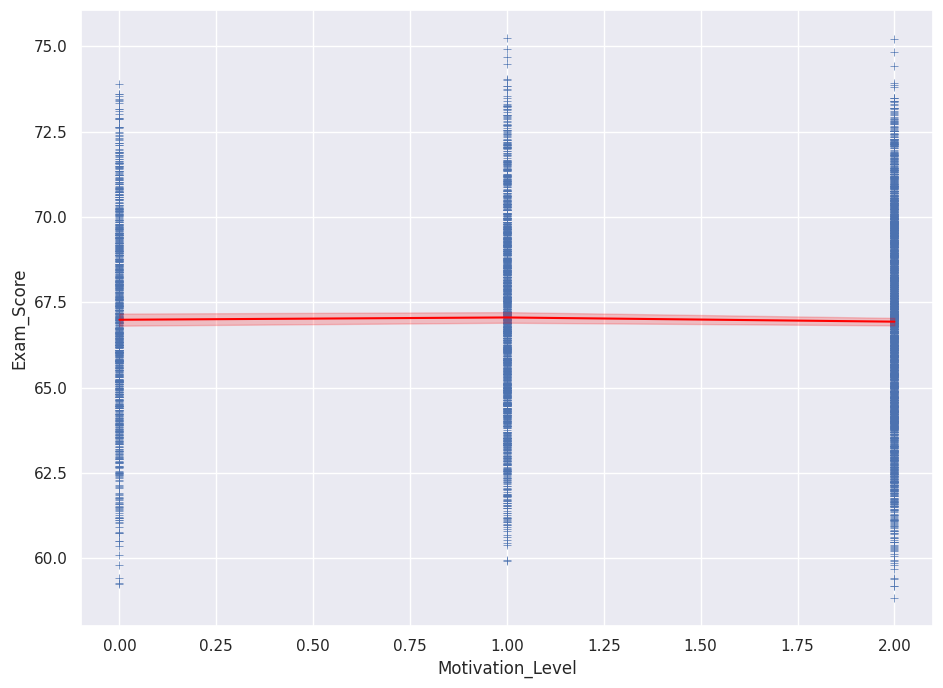

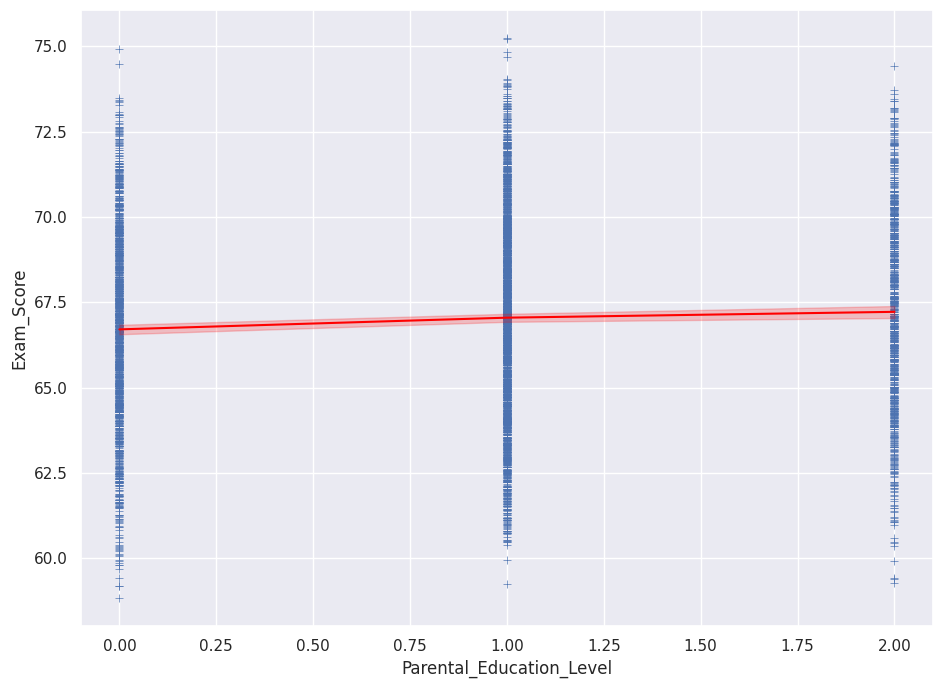

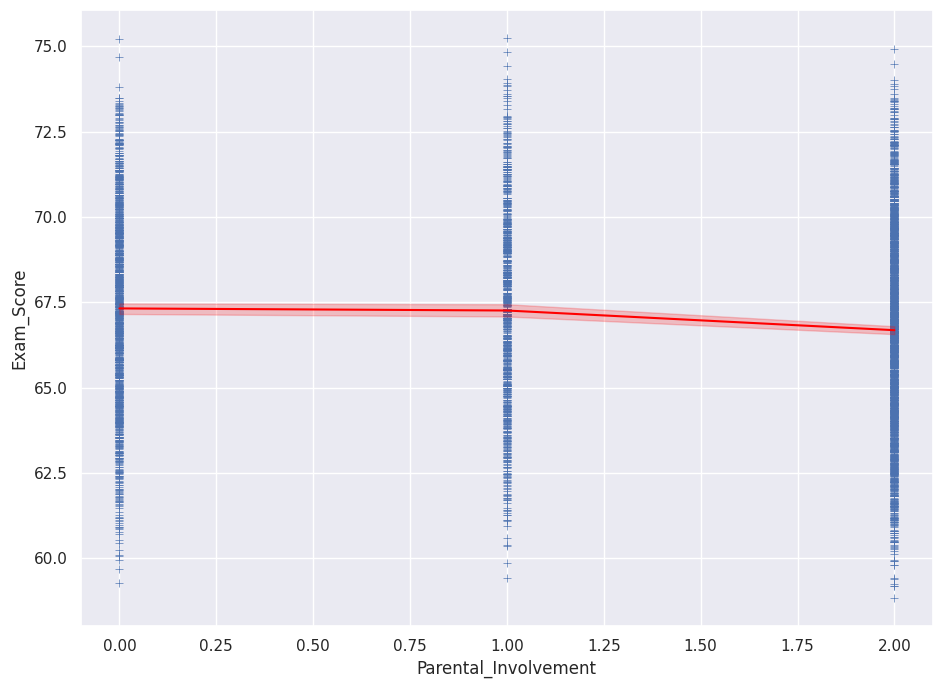

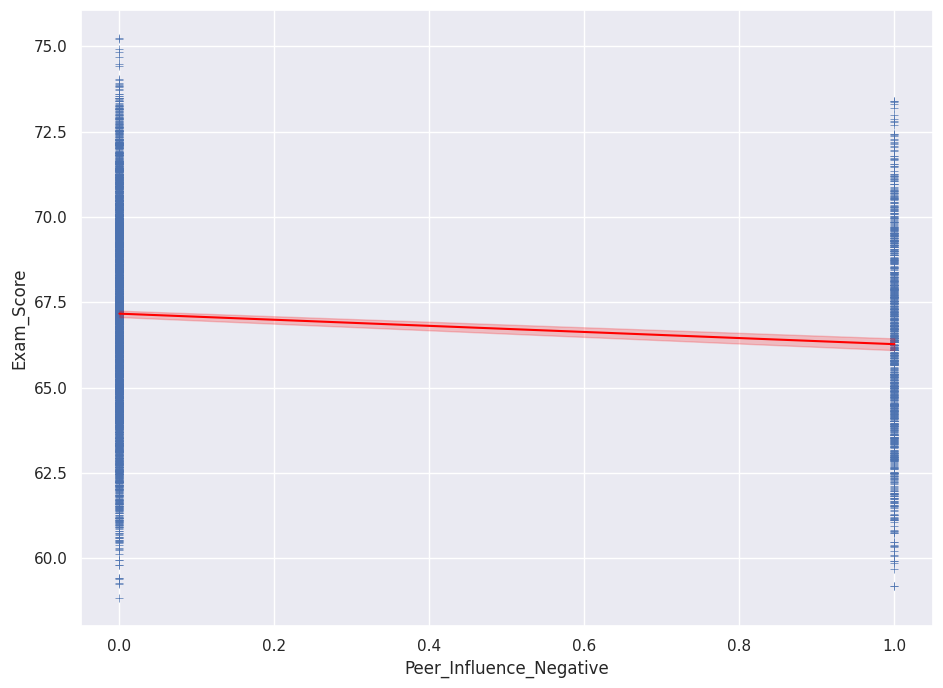

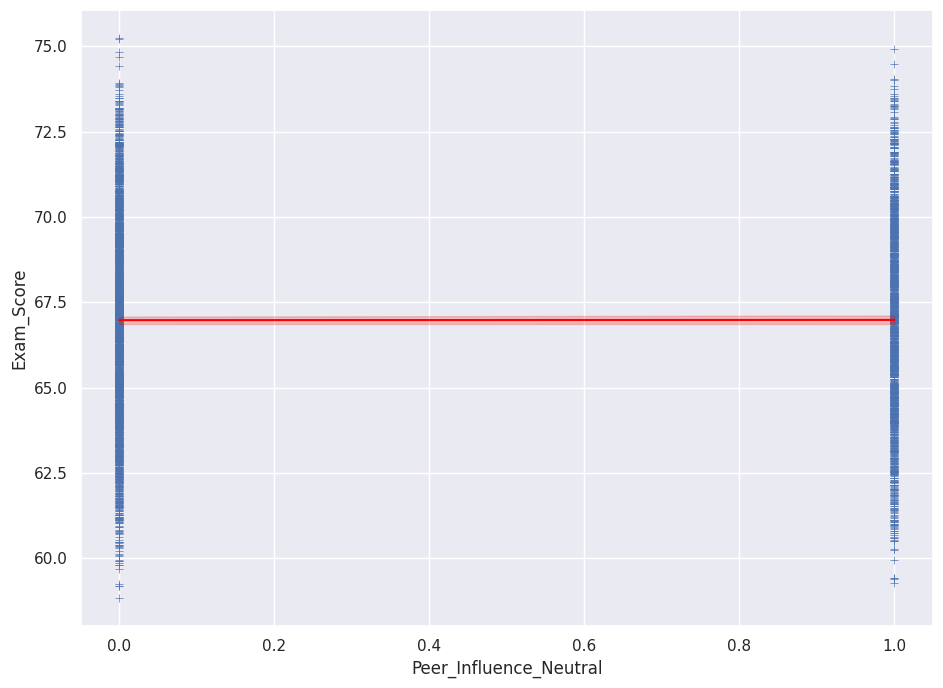

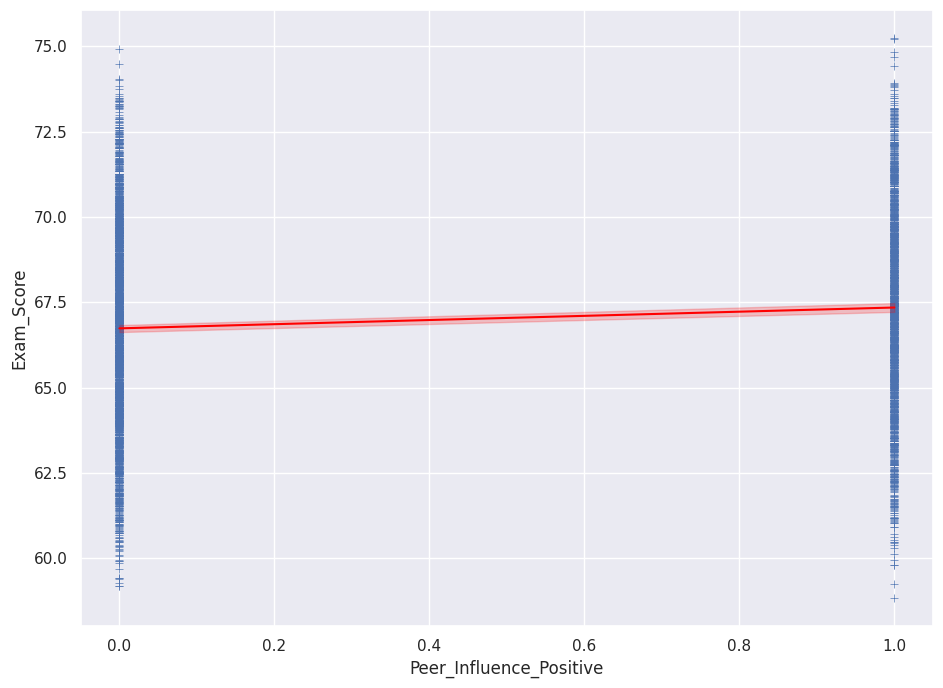

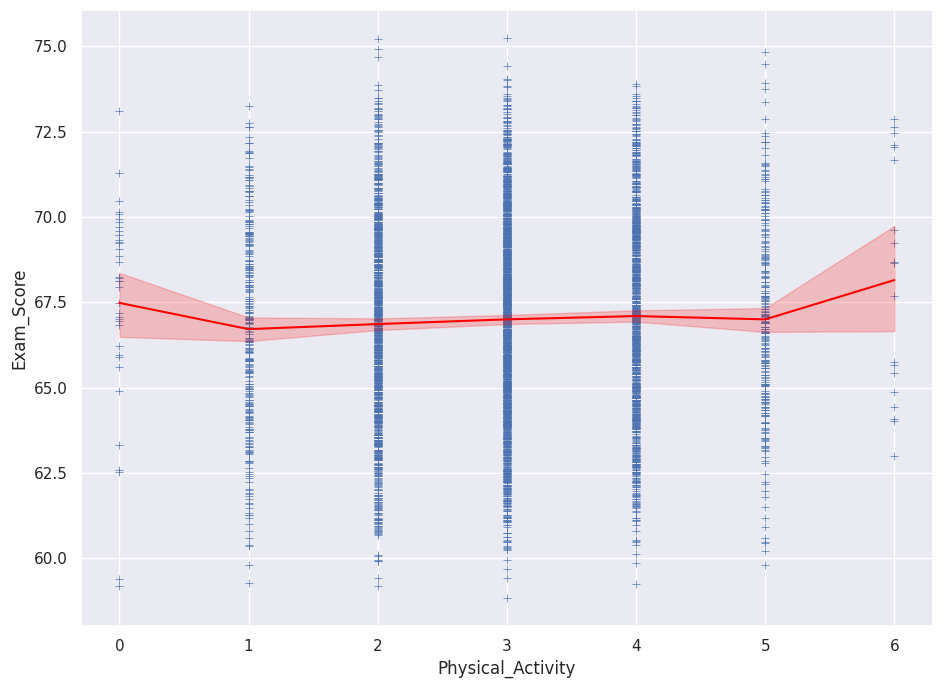

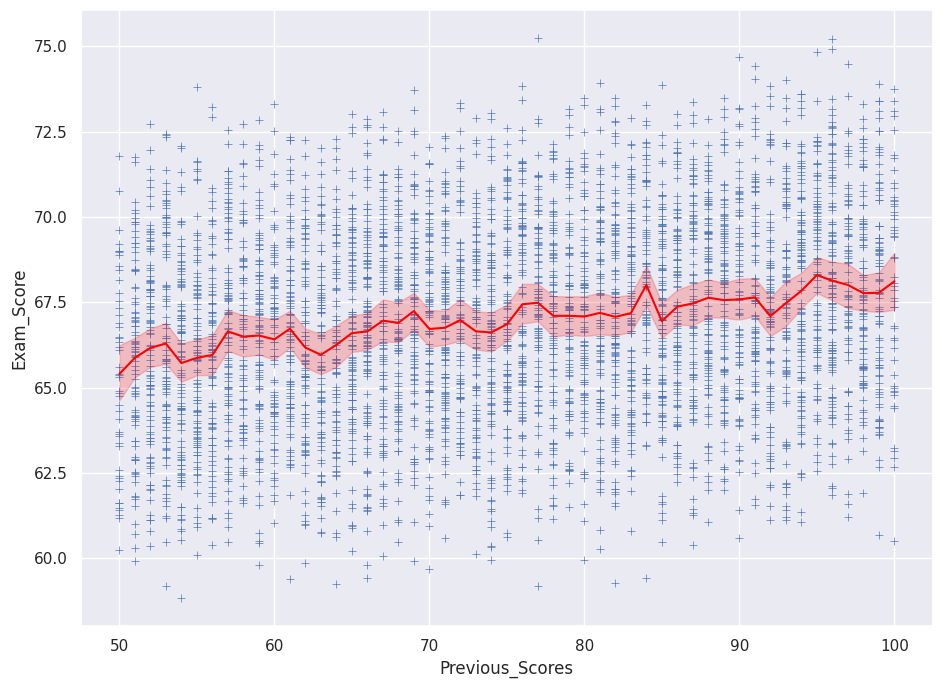

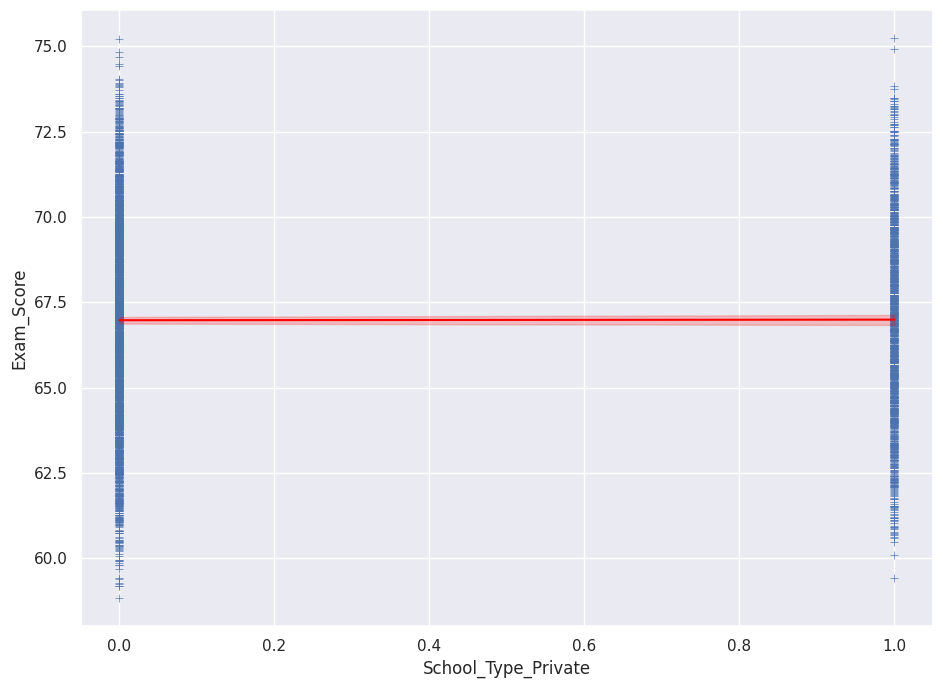

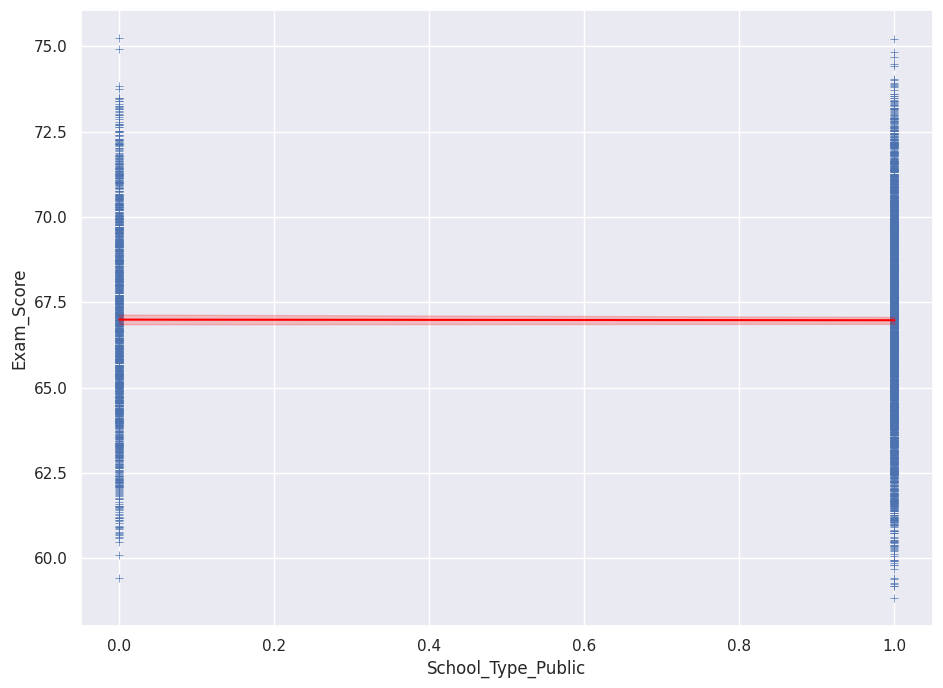

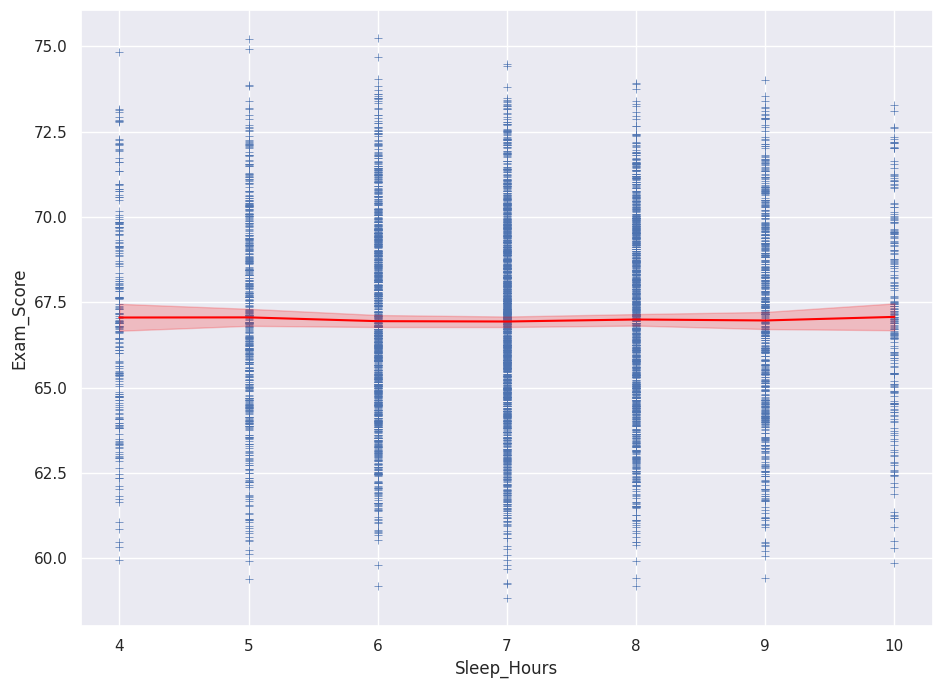

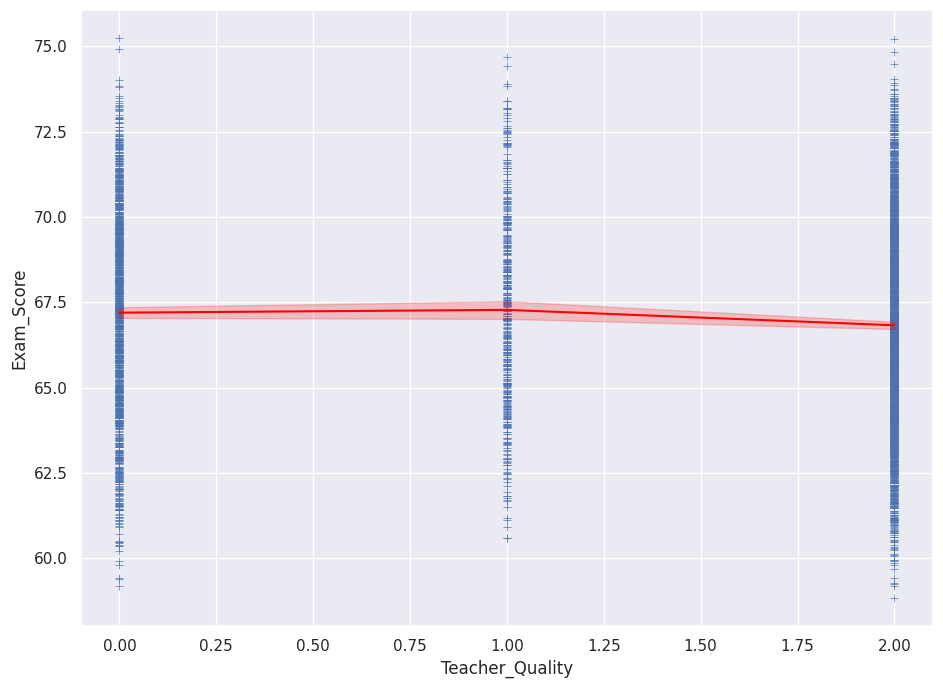

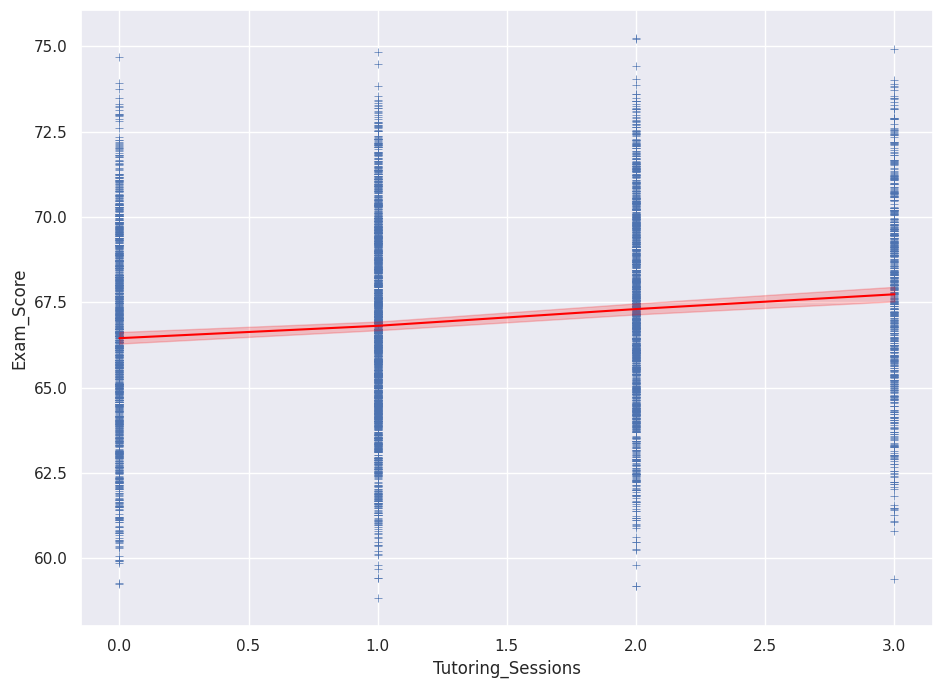

In [49]:

for col in x_train.columns:
      sns.scatterplot(x =x_train[col], y = predicted, marker='+')
      sns.lineplot(x =x_train[col], y = predicted, color='red')
      plt.xlabel(col)
      plt.ylabel('Exam_Score')
      plt.show()

In [50]:
pp = model.predict(x_test)
print(pp)

[64.3445726  63.72038442 68.52962422 ... 66.32927974 64.02649562
 62.1224588 ]


In [51]:
from sklearn import metrics

Evaluation du Model

In [52]:
r2_score = metrics.r2_score(y_train, predicted)
mae = metrics.mean_absolute_error(y_train, predicted)
rsme = metrics.root_mean_squared_error(y_train, predicted)

print("R2 => ", r2_score)
print("MAE => ", mae)
print("RSME => ", rsme)

R2 =>  0.8745192359552587
MAE =>  0.8884332961830893
RSME =>  1.098791272701809


Le R2 score pour les donnes d'entrainnement et de tests sont proche donc il n'y pas de overfitting

In [53]:
r2_score_test =metrics.r2_score(y_test, pp)
r2_score_test

0.8816635830636197

Expression mathematique

In [54]:
intercept = model.intercept_
couef = model.coef_
print("Intercept => ", intercept)
print("couef => ", couef)

Intercept =>  40.28650763813861
couef =>  [-0.40012211  0.19626279  0.5040073  -0.23388535  0.23388535 -0.11433328
 -0.00723238  0.00723238  0.28614849 -0.50411135  0.50411135  0.48260921
 -0.48260921 -0.13618258  0.15901153 -0.39926933 -0.51748077  0.00578729
  0.51169349  0.21768195  0.04819315 -0.00255908  0.00255908  0.00831938
 -0.20697408  0.50367105]


In [55]:
model.score(x_test, y_test)
model.score(x_train, y_train)

0.8745192359552587

In [56]:
from sklearn.model_selection import cross_val_score, validation_curve, GridSearchCV, learning_curve

In [57]:
cross_val_score(model, x_train, y_train,cv=5, scoring='r2').mean()

np.float64(0.8730571410974178)

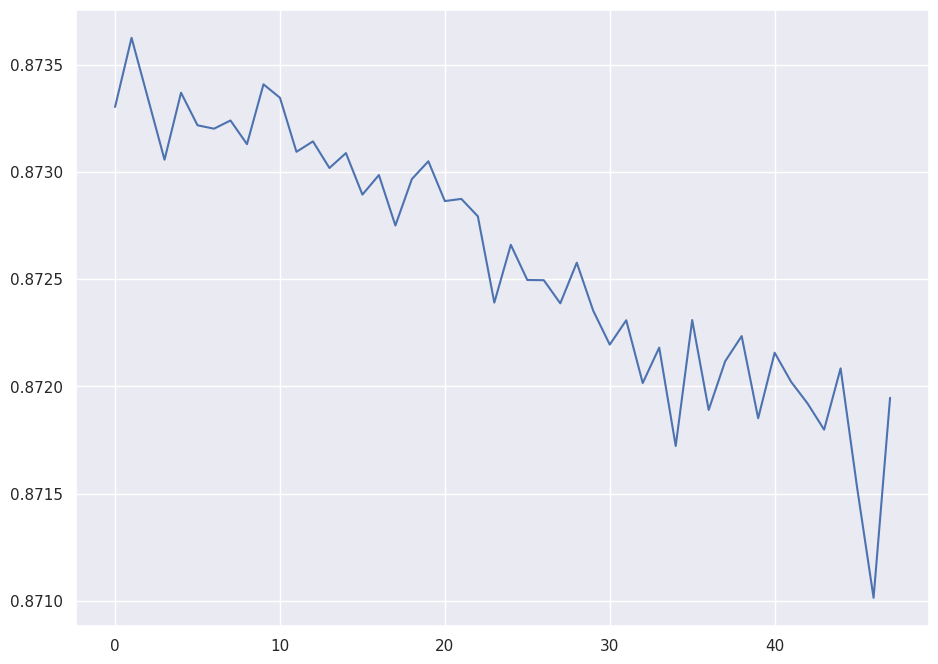

In [58]:
vall_score = []
for k in range(2,50):
      score = cross_val_score(model, x_train, y_train,cv=k).mean()
      vall_score.append(score)
plt.plot(vall_score)

In [59]:

model.get_params()
param_space = {
      'fit_intercept': [True, False],
      'positive': [True, False],
      
      }
grid_search= GridSearchCV(model, param_space, cv=3, scoring='r2')
grid_search.fit(x_train, y_train)
print(f'Best Hyperparameters : {grid_search.best_params_}')
print(f'Best Score: {grid_search.best_score_} ')
m = grid_search.best_estimator_
m.score(x_test, y_test)

Best Hyperparameters : {'fit_intercept': True, 'positive': False}
Best Score: 0.8736254227990771 


0.8816635830636197

[ 857 1238 1619 2001 2382 2763 3144 3525 3906 4288]


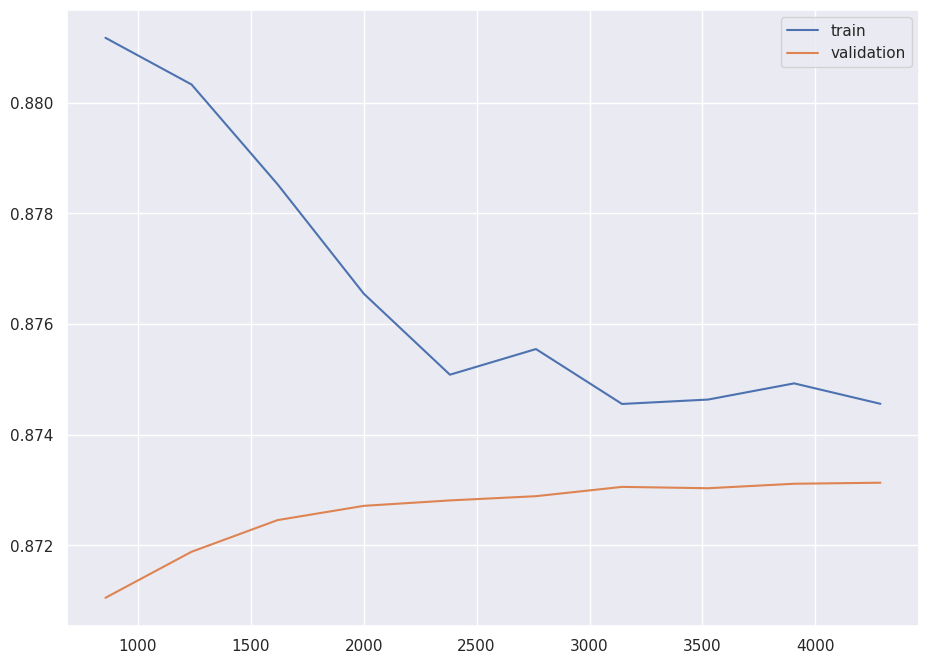

In [60]:
N, train_sc, val = learning_curve(m, x_train,y_train, train_sizes=np.linspace(0.2, 1.0, 10) , cv=10)
print(N)
plt.plot(N, train_sc.mean(axis=1), label='train')
plt.plot(N, val.mean(axis=1), label='validation')
plt.legend()

In [61]:
df_clean['Exam_Score'].shape

(5957,)

In [62]:
df_clean[['Exam_Score']].shape

(5957, 1)

In [63]:
from sklearn.model_selection import cross_val_score
crscore = cross_val_score(model, x, y, cv = 3)
crscore.std()

np.float64(0.0062935574362738)

Definir  Standard Kfold

In [64]:
from sklearn.model_selection import KFold

In [65]:
kf = KFold(n_splits=3, shuffle=True)

In [66]:
kfscore = cross_val_score(model, x, y.values.ravel(), cv=kf)
kfscore2 = cross_val_score(model, x, y.values.ravel(), cv=kf, scoring='r2')

In [67]:
kfscore

array([0.87038476, 0.87533986, 0.8787055 ])

In [68]:
kfscore.mean()

np.float64(0.8748100397019499)

In [69]:
kfscore.std()

np.float64(0.0034175217262927557)

In [70]:
kfscore2.mean()

np.float64(0.8749249870666618)

In [71]:
kfscore2.std()

np.float64(0.0020807755919579245)

Statified K fold

In [72]:
from sklearn.model_selection import StratifiedKFold

In [73]:
kf3 = StratifiedKFold(n_splits=3, shuffle=True)

In [74]:
kf3score = cross_val_score(model, x, y.values.ravel(), cv=kf3)

In [75]:
kf3score

array([0.87516264, 0.87633883, 0.87403425])

In [76]:
kf3score.mean()

np.float64(0.8751785742843191)

In [77]:
kf3score.std()

np.float64(0.0009409103231920651)

piplines example

In [78]:
from sklearn.preprocessing import StandardScaler

In [79]:
scale = StandardScaler()

In [80]:
from sklearn.pipeline import make_pipeline

In [81]:
pip1 = make_pipeline(scaler, model)

In [82]:
pip1.fit(x_train, y_train.values.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Access_to_Resources','Attendance','Distance_from_Home',...,'Sleep_Hours', 'Teacher_Quality','Tutoring_Sessions']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [83]:
scorespip = cross_val_score(pip1, x, y.values.ravel(), cv=10)

In [84]:
scorespip

array([0.86309941, 0.85331538, 0.87828217, 0.87056548, 0.88245851,
       0.89111607, 0.88203344, 0.87199921, 0.88733553, 0.86625153])

In [85]:
scorespip.mean()

np.float64(0.87464567126327)

In [86]:
scorespip.std()

np.float64(0.011151506459849818)

Decision Tree

In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [88]:
rl = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=18).fit(x_train, y_train)

In [89]:
prediction = rl.predict(x_test)
predicted

array([66.07442274, 61.52940067, 72.99854368, ..., 70.93564113,
       61.69828495, 70.24350405], shape=(4765,))

In [90]:
mse = mean_squared_error(y_test, prediction)
rmse = mse**.5


In [91]:
print(mse)
print(rmse)

2.343850240285273
1.5309638272295243


In [92]:
grid  = {
      'n_estimators': [100, 200],
      'max_depth' : [3,4,5,6,7],
      'min_samples_split' : [2]
}

In [93]:
cv_rfr = GridSearchCV(estimator=rl, param_grid=grid, cv=5)
cv_rfr.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=18)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'min_samples_split': [2], 'n_estimators': [100, 200]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the ver

In [94]:
cv_rfr.best_params_

{'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}

In [95]:
cv_rfr.best_score_

np.float64(0.8073723648605835)

In [96]:
cv_rfr.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",18
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [97]:
rff = RandomForestRegressor(n_estimators=200, max_depth=7, min_samples_split=2)

In [98]:
rff.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number 

In [99]:
p = rff.predict(x_test)

In [125]:
rff.score(x_test, y_test)

0.8176624171809087

In [100]:
msee = mean_squared_error(y_test, p)
msee

1.8006498479305932

In [101]:
msee**.5

1.341882948669739

SVM

In [102]:
from sklearn import svm

In [103]:
svr = svm.SVR()

In [104]:
svr.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [105]:
r = svr.predict(x_test)

In [106]:
mean_s_e = mean_squared_error(y_test, r)
mean_s_e
rmsesvr = mean_s_e**.5
rmsesvr

1.3505848746436022

In [ ]:
params = {
      'C' : [0.1, 1],
      'epsilon':[0.01, 0.1, 1],
      'kernel' : ['linear']
}

In [108]:
svrcv = GridSearchCV(svr, param_grid=params,cv =5 )

In [109]:
svrcv.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'kernel': ['linear']}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed duri

In [111]:
y_test.shape

(1192,)

In [115]:
best = svrcv.best_estimator_

In [117]:
Y = best.predict(x_test)

In [118]:
r2_score(y_test, Y)

0.8811931851154648

In [121]:
mean_squared_error(y_test ,Y)

1.173260442786551

In [123]:
best.score(x_test, y_test)

0.8811931851154648

In [124]:
best.score(x_train, y_train)

0.8742631449432021

In [126]:
from sklearn.metrics import median_absolute_error

In [127]:
median_absolute_error(y_test, Y)

0.7645786195789697

In [129]:
err = np.abs(y_test - Y)

(array([45., 55., 60., 68., 57., 59., 53., 52., 47., 61., 49., 53., 43.,
        47., 31., 36., 37., 30., 30., 29., 37., 22., 18., 27., 26., 26.,
        15., 17., 14.,  9.,  2.,  5.,  5.,  4.,  3.,  3.,  2.,  5.,  1.,
         2.,  0.,  0.,  0.,  0.,  1.,  0.,  3.,  1.,  1.,  1.]),
 array([0.00427213, 0.0746664 , 0.14506067, 0.21545494, 0.2858492 ,
        0.35624347, 0.42663774, 0.49703201, 0.56742628, 0.63782055,
        0.70821482, 0.77860909, 0.84900336, 0.91939763, 0.98979189,
        1.06018616, 1.13058043, 1.2009747 , 1.27136897, 1.34176324,
        1.41215751, 1.48255178, 1.55294605, 1.62334031, 1.69373458,
        1.76412885, 1.83452312, 1.90491739, 1.97531166, 2.04570593,
        2.1161002 , 2.18649447, 2.25688873, 2.327283  , 2.39767727,
        2.46807154, 2.53846581, 2.60886008, 2.67925435, 2.74964862,
        2.82004289, 2.89043716, 2.96083142, 3.03122569, 3.10161996,
        3.17201423, 3.2424085 , 3.31280277, 3.38319704, 3.45359131,
        3.52398558]),
 <BarContainer

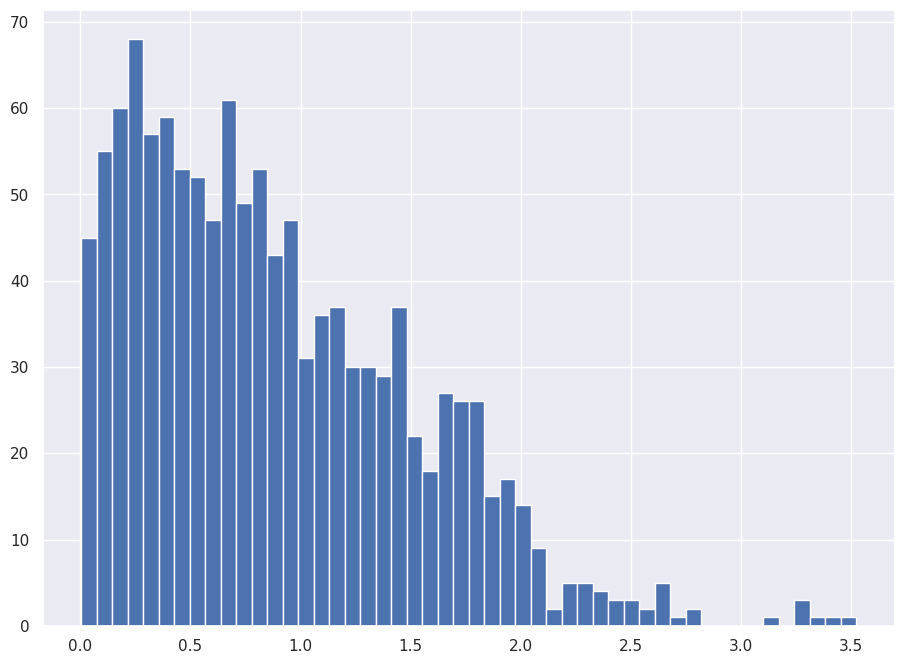

In [131]:
plt.hist(err, bins=50)

distribution expentielle

le model decrit de 87% des variations du exam score des etudiants

In [132]:
best.score(x, y)

0.8756789385226778